In [ ]:
# 4e: extended trading to 2026
# 4: this version fixes issue that cause constant volatilty
# 3: this version uses normalized PnL and assumes initial capital of 100k

          Date  Underlying (SPX Spot)  ATM Strike  DTE_F = FrontExp - Date  front straddle bid  front straddle ask  DTE_N = NextExp - Date  next straddle bid  next straddle ask  nearest straddle bid  nearest straddle ask  nearest IV  \
0   2025-01-02                5868.55        5870                       15               137.2               140.9                      50              247.1              251.3                 137.2                 140.9      14.310   
1   2025-01-03                5942.47        5940                       14               113.8               117.2                      49              227.3              230.9                 113.8                 117.2      12.103   
2   2025-01-06                5975.38        5975                       11               103.8               106.5                      46              218.3              221.3                 218.3                 221.3      12.896   
3   2025-01-07                5909.03        5910       

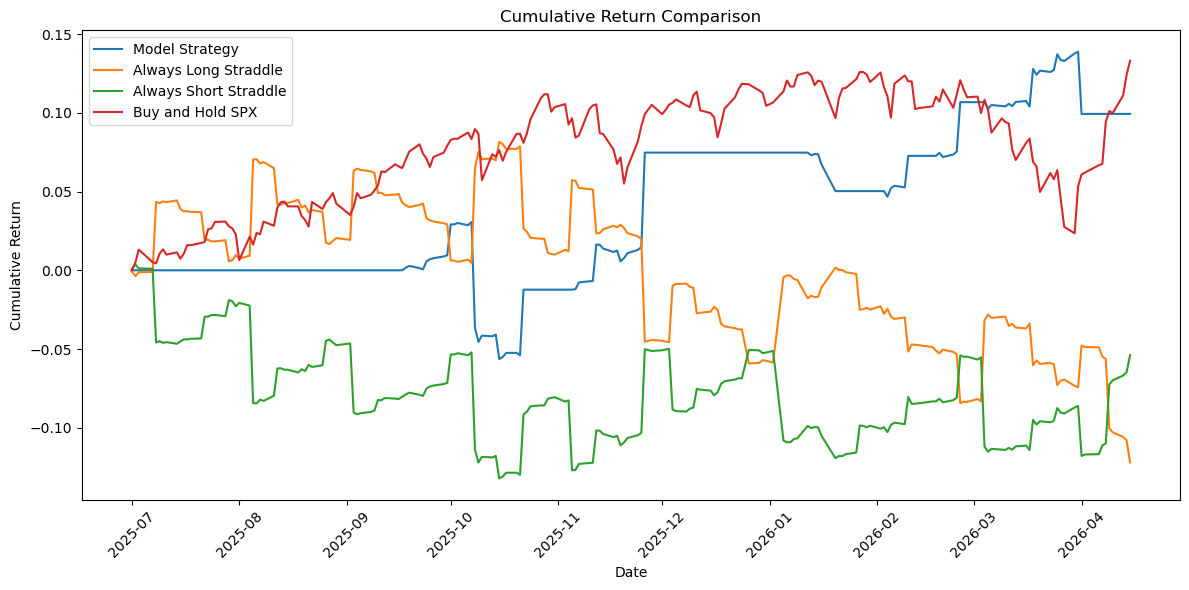

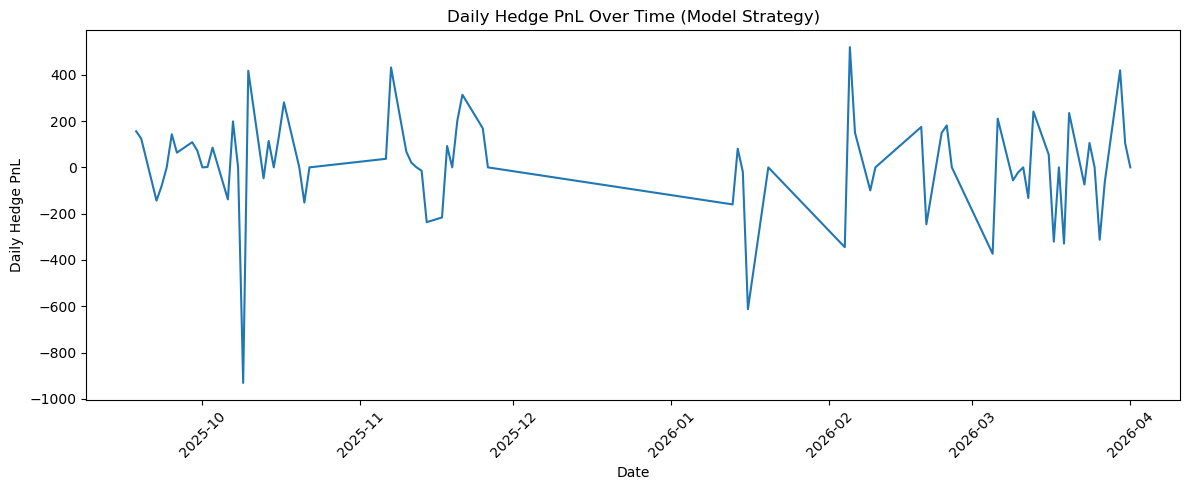

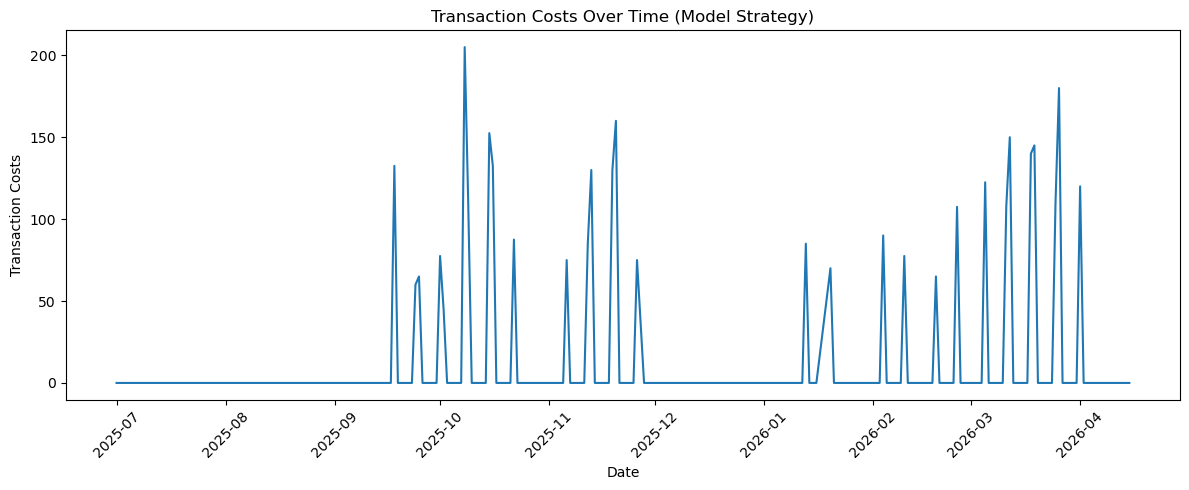

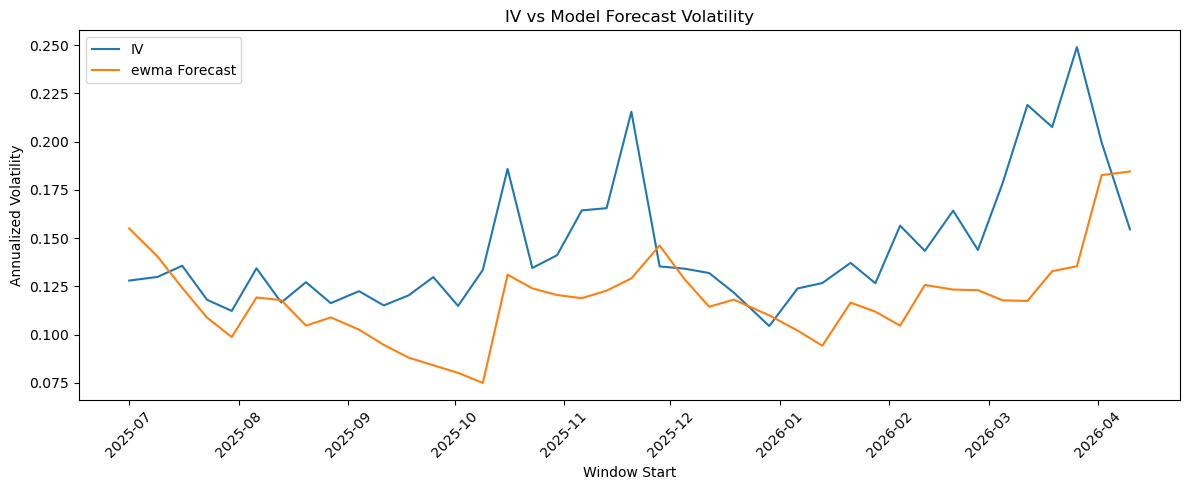


Average Straddle Ask during Trading Period: 228.01105527638188
Combined returns date range: 2023-01-04 00:00:00 to 2026-04-15 00:00:00
Trading options date range: 2025-07-01 00:00:00 to 2026-04-15 00:00:00


In [27]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ======================================================================================
# Hyperparameters
# ======================================================================================
VOL_MODEL = "ewma"                # "egarch", "ewma", "gjrgarch", "garch11"
TRADING_WINDOW_DAYS = 5             # number of option dates per walk-forward trading window
FORECAST_HORIZON_DAYS = 5           # volatility forecast horizon in trading days
TRADING_DAYS_PER_YEAR = 252
TRADE_THRESHOLD = 0.03              # minimum absolute vol edge to trade
MAX_EDGE_FILTER = 0.50              # do not trade if absolute edge exceeds this value
HEDGE_TC_PER_UNIT = 0.0             # hedge transaction cost per 1 unit of underlying rebalanced
EWMA_LAMBDA = 0.94                  # RiskMetrics lambda
GARCH_SIMULATIONS = 5000            # used for multi-step arch forecasts when needed
MIN_TRAIN_LENGTH = 60               # minimum return observations to fit model
HEDGE_NEUTRALITY_TOL = 1e-10        # tolerance for net delta after hedge
CONTRACT_MULTIPLIER = 50.0          # avg straddle premium ~206 x 50 ~= 10,300, about 10% of 100k capital
BUY_HOLD_UNITS = 1.0                # retained for reference; buy-and-hold now uses INITIAL_CAPITAL
MAX_DAILY_HEDGE_PRINT_ROWS = 20     # compact daily hedge diagnostics display

# Normalization / performance reporting
INITIAL_CAPITAL = 100_000.0         # common capital base for return normalization

RETURNS_CSV_PATH = Path("data/processed/SPY_Close_modeling_2.5y.csv")
RETURNS_FORECAST_CSV_PATH = Path("data/processed/SPY_Close_forecast_0.5y.csv")
OPTIONS_XLSX_PATH = Path("data/processed/options_data_2025&2026.xlsx")
OPTIONS_SHEET_NAME = "Delta_Trading"

INITIAL_TRAIN_START = pd.Timestamp("2023-01-04")
INITIAL_TRAIN_END = pd.Timestamp("2025-06-30")
TRADE_START = pd.Timestamp("2025-07-01")
TRADE_END: Optional[pd.Timestamp] = None   # resolved dynamically from options data

MODEL_STRATEGY_NAME = "Model Strategy"
LONG_BENCHMARK_NAME = "Always Long Straddle"
SHORT_BENCHMARK_NAME = "Always Short Straddle"
BUY_HOLD_NAME = "Buy and Hold SPX"


# ======================================================================================
# Data structures
# ======================================================================================
@dataclass
class ForecastResult:
    model: str
    annualized_vol: Optional[float]
    daily_variance_path: Optional[np.ndarray]
    fit_status: str


# ======================================================================================
# Utility helpers
# ======================================================================================
def require_columns(df: pd.DataFrame, required: List[str], df_name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")


def format_date(x) -> str:
    if pd.isna(x):
        return "NaT"
    return pd.Timestamp(x).strftime("%Y-%m-%d")


def print_section(title: str) -> None:
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)


def print_kv(title: str, items: List[Tuple[str, object]]) -> None:
    print_section(title)
    width = max(len(k) for k, _ in items)
    for k, v in items:
        print(f"{k:<{width}} : {v}")


def printable_df(df: pd.DataFrame, round_cols: Optional[List[str]] = None, decimals: int = 6) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if np.issubdtype(out[col].dtype, np.datetime64):
            out[col] = out[col].dt.strftime("%Y-%m-%d")

    if round_cols is None:
        round_cols = [
            c for c in out.columns
            if pd.api.types.is_numeric_dtype(out[c]) and not pd.api.types.is_bool_dtype(out[c])
        ]

    for col in round_cols:
        if col in out.columns and not pd.api.types.is_bool_dtype(out[col]):
            out[col] = out[col].astype(float).round(decimals)

    return out


def print_compact_df(title: str, df: pd.DataFrame, max_rows: int = 30, decimals: int = 6) -> None:
    print_section(title)
    if df.empty:
        print("<empty>")
        return

    view = printable_df(df, decimals=decimals)
    if len(view) <= max_rows:
        print(view.to_string(index=False))
    else:
        head_n = max_rows // 2
        tail_n = max_rows - head_n
        print(view.head(head_n).to_string(index=False))
        print(f"\n... ({len(view) - max_rows} rows omitted) ...\n")
        print(view.tail(tail_n).to_string(index=False))


def add_to_ledger(ledger: Dict[pd.Timestamp, float], date: pd.Timestamp, value: float = 0.0) -> None:
    d = pd.Timestamp(date)
    ledger[d] = ledger.get(d, 0.0) + float(value)


def compute_max_drawdown_from_cumulative_return(cumulative_return: pd.Series) -> float:
    cr = pd.Series(cumulative_return).astype(float)
    if cr.empty:
        return 0.0

    equity = 1.0 + cr
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    return float(drawdown.min())


def compute_sharpe(daily_returns: pd.Series, trading_days_per_year: int) -> float:
    rets = pd.Series(daily_returns).astype(float)
    if len(rets) <= 1:
        return np.nan
    std = float(rets.std(ddof=1))
    if std <= 0:
        return np.nan
    return float(np.sqrt(trading_days_per_year) * rets.mean() / std)


def add_normalized_performance_columns(
    daily_total_df: pd.DataFrame,
    initial_capital: float,
) -> pd.DataFrame:
    df = daily_total_df.copy()

    if initial_capital <= 0:
        raise ValueError("initial_capital must be positive.")

    df["Daily Return"] = df["Strategy PnL"] / initial_capital
    df["Cumulative Return"] = (1.0 + df["Daily Return"]).cumprod() - 1.0
    df["Equity Curve"] = initial_capital * (1.0 + df["Cumulative Return"])

    return df


# ======================================================================================
# Data loading
# ======================================================================================
def load_base_returns_data(modeling_path: Path, forecast_path: Path) -> pd.DataFrame:
    if not modeling_path.exists():
        raise FileNotFoundError(f"Returns CSV not found: {modeling_path}")
    if not forecast_path.exists():
        raise FileNotFoundError(f"Forecast returns CSV not found: {forecast_path}")

    modeling_df = pd.read_csv(modeling_path)
    forecast_df = pd.read_csv(forecast_path)

    require_columns(modeling_df, ["Date", "log_return"], "Modeling Returns CSV")
    require_columns(forecast_df, ["Date", "log_return"], "Forecast Returns CSV")

    modeling_df = modeling_df[["Date", "log_return"]].copy()
    forecast_df = forecast_df[["Date", "log_return"]].copy()

    returns_df = pd.concat([modeling_df, forecast_df], ignore_index=True)

    returns_df["Date"] = pd.to_datetime(returns_df["Date"], errors="coerce")
    returns_df["log_return"] = pd.to_numeric(returns_df["log_return"], errors="coerce")
    returns_df = returns_df.dropna(subset=["Date", "log_return"]).sort_values("Date")

    dupes = returns_df.duplicated(subset=["Date"], keep="first")
    if dupes.any():
        print(f"Warning: dropping {dupes.sum()} duplicate return rows by date (keeping first).")
        returns_df = returns_df.loc[~dupes].copy()

    if returns_df.empty:
        raise ValueError("Returns data is empty after parsing and cleaning.")

    return returns_df.reset_index(drop=True)


def load_options_data(path: Path, sheet_name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Options workbook not found: {path}")

    raw = pd.read_excel(path, sheet_name=sheet_name)
    required_raw_cols = [
        "Date",
        "nearest straddle bid",
        "nearest straddle ask",
        "Straddle Delta",
        "Underlying (SPX Spot)",
        "nearest IV",
    ]
    print(raw)
    require_columns(raw, required_raw_cols, "Options Excel sheet")

    rename_map = {
        "nearest straddle bid": "Straddle Bid",
        "nearest straddle ask": "Straddle Ask",
        "Straddle Delta": "Straddle Delta",
        "Underlying (SPX Spot)": "SPX Spot",
        "nearest IV": "IV",
    }

    df = raw.rename(columns=rename_map)[
        ["Date", "Straddle Bid", "Straddle Ask", "Straddle Delta", "SPX Spot", "IV"]
    ].copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Straddle Bid", "Straddle Ask", "Straddle Delta", "SPX Spot", "IV"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    before_drop = len(df)
    df = df.dropna(subset=["Date", "Straddle Bid", "Straddle Ask", "Straddle Delta", "SPX Spot", "IV"])
    dropped = before_drop - len(df)
    if dropped > 0:
        print(f"Warning: dropped {dropped} option rows with missing required values.")

    df["IV"] = df["IV"] / 100.0
    df = df.sort_values("Date")

    dupes = df.duplicated(subset=["Date"], keep="first")
    if dupes.any():
        print(f"Warning: dropping {dupes.sum()} duplicate option rows by date (keeping first).")
        df = df.loc[~dupes].copy()

    if df.empty:
        raise ValueError("Options data is empty after parsing and cleaning.")

    return df.reset_index(drop=True)


def build_returns_from_option_spot(options_df: pd.DataFrame) -> pd.DataFrame:
    spot_df = options_df[["Date", "SPX Spot"]].copy()
    spot_df = spot_df.dropna(subset=["Date", "SPX Spot"]).sort_values("Date").reset_index(drop=True)

    if spot_df.empty:
        raise ValueError("Cannot build returns from options data: SPX Spot series is empty.")

    dupes = spot_df.duplicated(subset=["Date"], keep="first")
    if dupes.any():
        print(f"Warning: dropping {dupes.sum()} duplicate SPX spot rows by date (keeping first).")
        spot_df = spot_df.loc[~dupes].copy()

    spot_df["prev_spot"] = spot_df["SPX Spot"].shift(1)
    valid = (spot_df["SPX Spot"] > 0) & (spot_df["prev_spot"] > 0)
    spot_df["log_return"] = np.where(valid, np.log(spot_df["SPX Spot"] / spot_df["prev_spot"]), np.nan)

    option_returns = spot_df.loc[spot_df["log_return"].notna(), ["Date", "log_return"]].copy()
    option_returns["return_source"] = "options_spot"

    if option_returns.empty:
        raise ValueError("Option-derived returns are empty after computing log returns from SPX Spot.")

    return option_returns.reset_index(drop=True)


def load_returns_data(
    modeling_path: Path,
    forecast_path: Path,
    options_df: pd.DataFrame,
) -> pd.DataFrame:
    base_returns_df = load_base_returns_data(modeling_path, forecast_path)
    option_returns_df = build_returns_from_option_spot(options_df)

    base_returns_df = base_returns_df.copy()
    base_returns_df["return_source"] = "csv"

    combined = pd.concat([base_returns_df, option_returns_df], ignore_index=True)
    combined["Date"] = pd.to_datetime(combined["Date"], errors="coerce")
    combined["log_return"] = pd.to_numeric(combined["log_return"], errors="coerce")
    combined = combined.dropna(subset=["Date", "log_return"]).copy()

    # Prefer option-derived returns whenever the date exists in the options workbook.
    source_priority = {"csv": 0, "options_spot": 1}
    combined["source_priority"] = combined["return_source"].map(source_priority).fillna(0).astype(int)
    combined = combined.sort_values(["Date", "source_priority"]).drop_duplicates(subset=["Date"], keep="last")
    combined = combined.sort_values("Date").reset_index(drop=True)

    if combined.empty:
        raise ValueError("Combined returns data is empty after merging CSV and option-derived returns.")

    print_kv(
        "Return Series Coverage",
        [
            ("CSV Returns Start", format_date(base_returns_df["Date"].min())),
            ("CSV Returns End", format_date(base_returns_df["Date"].max())),
            ("Option-Spot Returns Start", format_date(option_returns_df["Date"].min())),
            ("Option-Spot Returns End", format_date(option_returns_df["Date"].max())),
            ("Combined Returns Start", format_date(combined["Date"].min())),
            ("Combined Returns End", format_date(combined["Date"].max())),
        ],
    )

    return combined[["Date", "log_return"]].copy()


# ======================================================================================
# Volatility forecasts
# ======================================================================================
def import_arch_model():
    try:
        from arch import arch_model
    except ImportError as exc:
        raise ImportError(
            "The 'arch' package is required for egarch, gjrgarch, and garch11. "
            "Install it or switch VOL_MODEL to 'ewma'."
        ) from exc
    return arch_model


def ewma_forecast(returns: pd.Series, horizon: int, lam: float, trading_days: int) -> ForecastResult:
    r = pd.Series(returns).dropna().astype(float)
    if len(r) == 0:
        return ForecastResult(model="ewma", annualized_vol=None, daily_variance_path=None, fit_status="no_data")

    sigma2 = float(r.var(ddof=1))
    if not np.isfinite(sigma2) or sigma2 <= 0:
        sigma2 = float(np.mean(np.square(r))) if len(r) > 0 else 0.0

    for ret in r:
        sigma2 = lam * sigma2 + (1.0 - lam) * (ret ** 2)

    sigma2 = max(float(sigma2), 1e-16)
    var_path = np.repeat(sigma2, horizon)
    annualized_vol = float(np.sqrt(var_path.mean()) * np.sqrt(trading_days))
    return ForecastResult(model="ewma", annualized_vol=annualized_vol, daily_variance_path=var_path, fit_status="ok")


def garch_family_forecast(
    returns: pd.Series,
    model_name: str,
    horizon: int,
    trading_days: int,
    simulations: int,
) -> ForecastResult:
    arch_model = import_arch_model()

    r = pd.Series(returns).dropna().astype(float)
    if len(r) == 0:
        return ForecastResult(model=model_name, annualized_vol=None, daily_variance_path=None, fit_status="no_data")

    r_pct = r * 100.0

    if model_name == "egarch":
        model = arch_model(r_pct, mean="Zero", vol="EGARCH", p=1, o=0, q=1, dist="normal", rescale=False)
    elif model_name == "gjrgarch":
        model = arch_model(r_pct, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="normal", rescale=False)
    elif model_name == "garch11":
        model = arch_model(r_pct, mean="Zero", vol="GARCH", p=1, o=0, q=1, dist="normal", rescale=False)
    else:
        raise ValueError(f"Unsupported GARCH-family model: {model_name}")

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = model.fit(disp="off", show_warning=False)

        if horizon == 1:
            fcst = fit.forecast(horizon=1, reindex=False)
            var_path_pct2 = np.array([float(fcst.variance.iloc[-1, 0])], dtype=float)
        else:
            try:
                fcst = fit.forecast(
                    horizon=horizon,
                    method="simulation",
                    simulations=simulations,
                    reindex=False,
                )
                var_path_pct2 = fcst.variance.iloc[-1].to_numpy(dtype=float)
            except Exception:
                fcst = fit.forecast(horizon=1, reindex=False)
                one_step_var = float(fcst.variance.iloc[-1, 0])
                var_path_pct2 = np.repeat(one_step_var, horizon)

        var_path_pct2 = np.maximum(var_path_pct2, 1e-16)
        var_path = var_path_pct2 / (100.0 ** 2)
        annualized_vol = float(np.sqrt(var_path.mean()) * np.sqrt(trading_days))
        return ForecastResult(model=model_name, annualized_vol=annualized_vol, daily_variance_path=var_path, fit_status="ok")
    except Exception as exc:
        return ForecastResult(model=model_name, annualized_vol=None, daily_variance_path=None, fit_status=f"fit_failed: {exc}")


def forecast_volatility(
    returns: pd.Series,
    model_name: str,
    horizon: int,
    trading_days: int,
    ewma_lambda: float,
    simulations: int,
) -> ForecastResult:
    model_name = model_name.lower().strip()
    if model_name == "ewma":
        return ewma_forecast(returns, horizon=horizon, lam=ewma_lambda, trading_days=trading_days)
    if model_name in {"egarch", "gjrgarch", "garch11"}:
        return garch_family_forecast(
            returns=returns,
            model_name=model_name,
            horizon=horizon,
            trading_days=trading_days,
            simulations=simulations,
        )
    raise ValueError(f"Unsupported VOL_MODEL: {model_name}")


# ======================================================================================
# Walk-forward setup
# ======================================================================================
def make_windows(option_dates: pd.Series, window_len: int) -> List[pd.DatetimeIndex]:
    dates = pd.DatetimeIndex(pd.Series(option_dates).dropna().sort_values().unique())
    if len(dates) == 0:
        raise ValueError("No option dates available to create trading windows.")
    return [dates[i: i + window_len] for i in range(0, len(dates), window_len)]


def trade_direction_from_edge(vol_edge: Optional[float], threshold: float, max_edge: float) -> Tuple[str, bool, int]:
    if vol_edge is None or not np.isfinite(vol_edge):
        return "Flat", False, 0
    if abs(vol_edge) < threshold:
        return "Flat", False, 0
    if abs(vol_edge) > max_edge:
        return "Flat", False, 0
    if vol_edge > 0:
        return "Long", True, 1
    if vol_edge < 0:
        return "Short", True, -1
    return "Flat", False, 0


def build_walkforward_payloads(
    returns_df: pd.DataFrame,
    trading_options: pd.DataFrame,
    trade_start: pd.Timestamp,
    trade_end: pd.Timestamp,
) -> Tuple[List[dict], pd.DataFrame]:
    initial_train_returns = returns_df.loc[
        (returns_df["Date"] >= INITIAL_TRAIN_START) & (returns_df["Date"] <= INITIAL_TRAIN_END)
    ].copy()

    if initial_train_returns.empty:
        raise ValueError("Initial training period is empty.")

    returns_trade_dates = pd.DatetimeIndex(
        returns_df.loc[
            (returns_df["Date"] >= trade_start) & (returns_df["Date"] <= trade_end),
            "Date",
        ].sort_values().unique()
    )
    option_trade_dates = pd.DatetimeIndex(trading_options["Date"].sort_values().unique())
    common_trade_dates = option_trade_dates.intersection(returns_trade_dates)

    if len(common_trade_dates) == 0:
        raise ValueError(
            "No overlapping trade dates found between returns_df and trading_options in the trade period. "
            "Walk-forward updating requires return data during the trading period."
        )

    trading_options_common = (
        trading_options.loc[trading_options["Date"].isin(common_trade_dates)]
        .copy()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    windows = make_windows(trading_options_common["Date"], TRADING_WINDOW_DAYS)

    training_history = initial_train_returns.copy()
    current_train_cutoff = pd.Timestamp(INITIAL_TRAIN_END)
    payloads: List[dict] = []

    for window_index, window_dates in enumerate(windows, start=1):
        window_df = (
            trading_options_common.loc[trading_options_common["Date"].isin(window_dates)]
            .copy()
            .sort_values("Date")
            .reset_index(drop=True)
        )
        if window_df.empty:
            raise ValueError(f"Window {window_index} produced empty option data.")

        window_start = pd.Timestamp(window_df.iloc[0]["Date"])
        new_returns_for_training = returns_df.loc[
            (returns_df["Date"] > current_train_cutoff) & (returns_df["Date"] < window_start)
        ].copy()

        if not new_returns_for_training.empty:
            training_history = (
                pd.concat([training_history, new_returns_for_training], ignore_index=True)
                .drop_duplicates(subset=["Date"], keep="first")
                .sort_values("Date")
                .reset_index(drop=True)
            )
            current_train_cutoff = pd.Timestamp(training_history["Date"].max())

        train_start_used = pd.Timestamp(training_history["Date"].min())
        train_end_used = pd.Timestamp(training_history["Date"].max())
        train_obs = int(len(training_history))

        if train_obs < MIN_TRAIN_LENGTH:
            forecast = ForecastResult(
                model=VOL_MODEL,
                annualized_vol=None,
                daily_variance_path=None,
                fit_status=f"insufficient_training_obs<{MIN_TRAIN_LENGTH}",
            )
        else:
            forecast = forecast_volatility(
                returns=training_history["log_return"],
                model_name=VOL_MODEL,
                horizon=FORECAST_HORIZON_DAYS,
                trading_days=TRADING_DAYS_PER_YEAR,
                ewma_lambda=EWMA_LAMBDA,
                simulations=GARCH_SIMULATIONS,
            )

        first_row = window_df.iloc[0]
        last_row = window_df.iloc[-1]
        iv = float(first_row["IV"])
        forecast_vol = forecast.annualized_vol
        vol_edge = np.nan if forecast_vol is None else float(forecast_vol - iv)

        payloads.append(
            {
                "window_index": window_index,
                "window_start": pd.Timestamp(first_row["Date"]),
                "window_end": pd.Timestamp(last_row["Date"]),
                "window_df": window_df,
                "forecast_vol": forecast_vol,
                "iv": iv,
                "vol_edge": vol_edge,
                "forecast_status": forecast.fit_status,
                "train_start": train_start_used,
                "train_end_used": train_end_used,
                "train_obs": train_obs,
                "option_rows_in_window": int(len(window_df)),
            }
        )

        last_row_date = pd.Timestamp(last_row["Date"])
        realized_window_returns = returns_df.loc[
            (returns_df["Date"] > current_train_cutoff) & (returns_df["Date"] <= last_row_date)
        ].copy()

        if not realized_window_returns.empty:
            training_history = (
                pd.concat([training_history, realized_window_returns], ignore_index=True)
                .drop_duplicates(subset=["Date"], keep="first")
                .sort_values("Date")
                .reset_index(drop=True)
            )
            current_train_cutoff = pd.Timestamp(training_history["Date"].max())

    payload_df = pd.DataFrame(
        [
            {
                "Window Start": p["window_start"],
                "Window End": p["window_end"],
                "Forecast Vol": p["forecast_vol"],
                "IV": p["iv"],
                "Vol Edge": p["vol_edge"],
                "Forecast Status": p["forecast_status"],
                "Train Start": p["train_start"],
                "Train End Used": p["train_end_used"],
                "Train Obs": p["train_obs"],
                "Option Rows In Window": p["option_rows_in_window"],
            }
            for p in payloads
        ]
    )

    return payloads, payload_df


# ======================================================================================
# Strategy engine
# ======================================================================================
def resolve_strategy_direction(strategy_mode: str, vol_edge: Optional[float]) -> Tuple[str, bool, int]:
    strategy_mode = strategy_mode.lower().strip()

    if strategy_mode == "model":
        return trade_direction_from_edge(vol_edge=vol_edge, threshold=TRADE_THRESHOLD, max_edge=MAX_EDGE_FILTER)

    if strategy_mode == "always_long":
        return "Long", True, 1

    if strategy_mode == "always_short":
        return "Short", True, -1

    raise ValueError(f"Unsupported strategy_mode: {strategy_mode}")


def calculate_option_pnl_and_tc(
    entry_bid: float,
    entry_ask: float,
    exit_bid: float,
    exit_ask: float,
    direction_sign: int,
    multiplier: float,
) -> Tuple[float, float, float, float]:
    entry_tc = 0.5 * abs(entry_ask - entry_bid) * multiplier
    exit_tc = 0.5 * abs(exit_ask - exit_bid) * multiplier
    option_tc = entry_tc + exit_tc

    if direction_sign == 1:
        straddle_pnl = (exit_bid - entry_ask) * multiplier
    elif direction_sign == -1:
        straddle_pnl = (entry_bid - exit_ask) * multiplier
    else:
        straddle_pnl = 0.0

    return float(straddle_pnl), float(option_tc), float(entry_tc), float(exit_tc)


def execute_trade_window(
    window_df: pd.DataFrame,
    direction: str,
    trade_taken: bool,
    direction_sign: int,
) -> Tuple[Dict[str, float], List[Dict[str, object]], Dict[pd.Timestamp, float], Dict[pd.Timestamp, float]]:
    option_tc = 0.0
    hedge_tc = 0.0
    total_tc = 0.0
    straddle_pnl = 0.0
    hedge_pnl = 0.0
    window_pnl = 0.0

    hedge_records: List[Dict[str, object]] = []
    daily_pnl_ledger: Dict[pd.Timestamp, float] = {}
    daily_tc_ledger: Dict[pd.Timestamp, float] = {}

    if not trade_taken or direction_sign == 0:
        return (
            {
                "Option TC": option_tc,
                "Hedge TC": hedge_tc,
                "Total TC": total_tc,
                "Straddle PnL": straddle_pnl,
                "Hedge PnL": hedge_pnl,
                "Window PnL": window_pnl,
            },
            hedge_records,
            daily_pnl_ledger,
            daily_tc_ledger,
        )

    first_row = window_df.iloc[0]
    last_row = window_df.iloc[-1]

    straddle_pnl, option_tc, entry_option_tc, exit_option_tc = calculate_option_pnl_and_tc(
        entry_bid=float(first_row["Straddle Bid"]),
        entry_ask=float(first_row["Straddle Ask"]),
        exit_bid=float(last_row["Straddle Bid"]),
        exit_ask=float(last_row["Straddle Ask"]),
        direction_sign=direction_sign,
        multiplier=CONTRACT_MULTIPLIER,
    )

    add_to_ledger(daily_tc_ledger, pd.Timestamp(first_row["Date"]), entry_option_tc)
    add_to_ledger(daily_tc_ledger, pd.Timestamp(last_row["Date"]), exit_option_tc)

    prev_hedge_pos = 0.0

    if len(window_df) >= 2:
        for i in range(len(window_df) - 1):
            cur = window_df.iloc[i]
            nxt = window_df.iloc[i + 1]

            cur_date = pd.Timestamp(cur["Date"])
            cur_spot = float(cur["SPX Spot"])
            nxt_spot = float(nxt["SPX Spot"])
            cur_delta = float(cur["Straddle Delta"])

            target_hedge_pos = -direction_sign * cur_delta
            net_delta_after_hedge = direction_sign * cur_delta + target_hedge_pos

            daily_hedge_tc = abs(target_hedge_pos - prev_hedge_pos) * HEDGE_TC_PER_UNIT * CONTRACT_MULTIPLIER
            daily_hedge_pnl = target_hedge_pos * (nxt_spot - cur_spot) * CONTRACT_MULTIPLIER

            hedge_tc += daily_hedge_tc
            hedge_pnl += daily_hedge_pnl

            hedge_records.append(
                {
                    "Date": cur_date,
                    "Window Start": pd.Timestamp(first_row["Date"]),
                    "Direction": direction,
                    "SPX Spot": cur_spot,
                    "Straddle Delta": cur_delta,
                    "Hedge Position": target_hedge_pos,
                    "Net Delta After Hedge": net_delta_after_hedge,
                    "Daily Hedge PnL": daily_hedge_pnl,
                    "Daily Hedge TC": daily_hedge_tc,
                }
            )

            add_to_ledger(daily_pnl_ledger, cur_date, daily_hedge_pnl - daily_hedge_tc)
            add_to_ledger(daily_tc_ledger, cur_date, daily_hedge_tc)

            prev_hedge_pos = target_hedge_pos

    final_date = pd.Timestamp(last_row["Date"])
    final_delta = float(last_row["Straddle Delta"])
    final_spot = float(last_row["SPX Spot"])

    unwind_tc = abs(prev_hedge_pos) * HEDGE_TC_PER_UNIT * CONTRACT_MULTIPLIER
    hedge_tc += unwind_tc

    hedge_records.append(
        {
            "Date": final_date,
            "Window Start": pd.Timestamp(first_row["Date"]),
            "Direction": direction,
            "SPX Spot": final_spot,
            "Straddle Delta": final_delta,
            "Hedge Position": 0.0,
            "Net Delta After Hedge": 0.0,
            "Daily Hedge PnL": 0.0,
            "Daily Hedge TC": unwind_tc,
        }
    )

    add_to_ledger(daily_pnl_ledger, final_date, straddle_pnl - unwind_tc)
    add_to_ledger(daily_tc_ledger, final_date, unwind_tc)

    total_tc = option_tc + hedge_tc
    window_pnl = straddle_pnl + hedge_pnl - hedge_tc

    return (
        {
            "Option TC": float(option_tc),
            "Hedge TC": float(hedge_tc),
            "Total TC": float(total_tc),
            "Straddle PnL": float(straddle_pnl),
            "Hedge PnL": float(hedge_pnl),
            "Window PnL": float(window_pnl),
        },
        hedge_records,
        daily_pnl_ledger,
        daily_tc_ledger,
    )


def finalize_daily_totals(
    trading_dates: pd.DatetimeIndex,
    daily_pnl_ledger: Dict[pd.Timestamp, float],
    daily_tc_ledger: Dict[pd.Timestamp, float],
    initial_capital: float,
) -> pd.DataFrame:
    daily_total_df = pd.DataFrame(index=trading_dates)
    daily_total_df.index.name = "Date"
    daily_total_df["Strategy PnL"] = 0.0
    daily_total_df["Transaction Costs"] = 0.0

    for dt, pnl in daily_pnl_ledger.items():
        if dt not in daily_total_df.index:
            daily_total_df.loc[dt] = 0.0
        daily_total_df.loc[dt, "Strategy PnL"] += pnl

    for dt, tc in daily_tc_ledger.items():
        if dt not in daily_total_df.index:
            daily_total_df.loc[dt] = 0.0
        daily_total_df.loc[dt, "Transaction Costs"] += tc

    daily_total_df = daily_total_df.sort_index()
    daily_total_df["Cumulative PnL"] = daily_total_df["Strategy PnL"].cumsum()
    daily_total_df = daily_total_df.reset_index()

    daily_total_df = add_normalized_performance_columns(
        daily_total_df=daily_total_df,
        initial_capital=initial_capital,
    )

    return daily_total_df


def summarize_hedge_quality(daily_hedge_df: pd.DataFrame) -> pd.DataFrame:
    if daily_hedge_df.empty:
        max_abs_net_delta = 0.0
        mean_abs_net_delta = 0.0
        neutralized = True
    else:
        max_abs_net_delta = float(daily_hedge_df["Net Delta After Hedge"].abs().max())
        mean_abs_net_delta = float(daily_hedge_df["Net Delta After Hedge"].abs().mean())
        neutralized = bool(max_abs_net_delta <= HEDGE_NEUTRALITY_TOL)

    return pd.DataFrame(
        {
            "Metric": [
                "Max |Net Delta After Hedge|",
                "Mean |Net Delta After Hedge|",
                "Hedging Effectively Neutralized Each Day",
            ],
            "Value": [max_abs_net_delta, mean_abs_net_delta, neutralized],
        }
    )


def summarize_strategy_performance(
    strategy_name: str,
    daily_total_df: pd.DataFrame,
    window_results: Optional[pd.DataFrame],
) -> pd.DataFrame:
    overall_pnl = float(daily_total_df["Strategy PnL"].sum())
    total_return = float(daily_total_df["Cumulative Return"].iloc[-1]) if not daily_total_df.empty else 0.0
    sharpe = compute_sharpe(daily_total_df["Daily Return"], TRADING_DAYS_PER_YEAR)
    max_drawdown = compute_max_drawdown_from_cumulative_return(daily_total_df["Cumulative Return"])
    total_tc = float(daily_total_df["Transaction Costs"].sum())

    if window_results is None or window_results.empty:
        total_windows = 1
        trades_taken = 1
    else:
        total_windows = int(len(window_results))
        trades_taken = int(window_results["Trade Taken"].sum())

    return pd.DataFrame(
        {
            "Strategy": [strategy_name],
            "Overall PnL": [overall_pnl],
            "Total Return": [total_return],
            "Sharpe Ratio": [sharpe],
            "Max Drawdown": [max_drawdown],
            "Total TC": [total_tc],
            "Total Windows": [total_windows],
            "Trades Taken": [trades_taken],
        }
    )


def run_straddle_strategy(
    strategy_mode: str,
    strategy_name: str,
    window_payloads: List[dict],
    trading_dates: pd.DatetimeIndex,
    initial_capital: float,
) -> Dict[str, pd.DataFrame]:
    window_records: List[Dict[str, object]] = []
    hedge_records: List[Dict[str, object]] = []

    daily_pnl_ledger: Dict[pd.Timestamp, float] = {}
    daily_tc_ledger: Dict[pd.Timestamp, float] = {}

    cumulative_pnl = 0.0

    for payload in window_payloads:
        window_df = payload["window_df"]
        vol_edge = payload["vol_edge"]
        vol_edge_for_decision = None if pd.isna(vol_edge) else float(vol_edge)

        direction, trade_taken, direction_sign = resolve_strategy_direction(strategy_mode, vol_edge_for_decision)

        window_metrics, window_hedge_records, window_pnl_ledger, window_tc_ledger = execute_trade_window(
            window_df=window_df,
            direction=direction,
            trade_taken=trade_taken,
            direction_sign=direction_sign,
        )

        for dt, pnl in window_pnl_ledger.items():
            add_to_ledger(daily_pnl_ledger, dt, pnl)
        for dt, tc in window_tc_ledger.items():
            add_to_ledger(daily_tc_ledger, dt, tc)

        hedge_records.extend(window_hedge_records)

        cumulative_pnl += window_metrics["Window PnL"]

        window_records.append(
            {
                "Window Start": payload["window_start"],
                "Direction": direction,
                "Forecast Vol": payload["forecast_vol"],
                "IV": payload["iv"],
                "Vol Edge": payload["vol_edge"],
                "Trade Taken": bool(trade_taken),
                "Train Start": payload["train_start"],
                "Train End Used": payload["train_end_used"],
                "Train Obs": payload["train_obs"],
                "Option TC": window_metrics["Option TC"],
                "Hedge TC": window_metrics["Hedge TC"],
                "Total TC": window_metrics["Total TC"],
                "Straddle PnL": window_metrics["Straddle PnL"],
                "Hedge PnL": window_metrics["Hedge PnL"],
                "Window PnL": window_metrics["Window PnL"],
                "Cumulative PnL": cumulative_pnl,
                "Forecast Status": payload["forecast_status"],
                "Option Rows In Window": payload["option_rows_in_window"],
            }
        )

    window_results = pd.DataFrame(window_records)
    daily_hedge_df = pd.DataFrame(hedge_records)
    if not daily_hedge_df.empty:
        daily_hedge_df = daily_hedge_df.sort_values(["Window Start", "Date"]).reset_index(drop=True)

    daily_total_df = finalize_daily_totals(
        trading_dates=trading_dates,
        daily_pnl_ledger=daily_pnl_ledger,
        daily_tc_ledger=daily_tc_ledger,
        initial_capital=initial_capital,
    )

    if not np.isclose(float(window_results["Window PnL"].sum()), float(daily_total_df["Strategy PnL"].sum()), atol=1e-8):
        diff = float(window_results["Window PnL"].sum() - daily_total_df["Strategy PnL"].sum())
        raise ValueError(f"{strategy_name} PnL reconciliation failed. Window sum minus daily sum = {diff:.10f}")

    hedge_quality = summarize_hedge_quality(daily_hedge_df)
    tc_summary = window_results[["Window Start", "Direction", "Option TC", "Hedge TC", "Total TC"]].copy()
    performance = summarize_strategy_performance(strategy_name, daily_total_df, window_results)

    return {
        "window_results": window_results,
        "daily_hedge_diagnostics": daily_hedge_df,
        "hedge_quality_summary": hedge_quality,
        "transaction_cost_summary": tc_summary,
        "daily_total_pnl": daily_total_df,
        "performance_metrics": performance,
    }


def run_buy_and_hold(trading_options: pd.DataFrame, initial_capital: float) -> Dict[str, pd.DataFrame]:
    spot_df = trading_options[["Date", "SPX Spot"]].copy().sort_values("Date").reset_index(drop=True)
    if spot_df.empty:
        raise ValueError("Trading-period spot data is empty for buy-and-hold benchmark.")

    spot_df["Daily Return"] = spot_df["SPX Spot"].pct_change().fillna(0.0)
    spot_df["Strategy PnL"] = spot_df["Daily Return"] * initial_capital
    spot_df["Transaction Costs"] = 0.0
    spot_df["Cumulative Return"] = (1.0 + spot_df["Daily Return"]).cumprod() - 1.0
    spot_df["Equity Curve"] = initial_capital * (1.0 + spot_df["Cumulative Return"])
    spot_df["Cumulative PnL"] = spot_df["Equity Curve"] - initial_capital

    daily_total_df = spot_df[
        ["Date", "Strategy PnL", "Transaction Costs", "Cumulative PnL", "Daily Return", "Cumulative Return", "Equity Curve"]
    ].copy()

    performance = summarize_strategy_performance(BUY_HOLD_NAME, daily_total_df, None)

    return {
        "daily_total_pnl": daily_total_df,
        "performance_metrics": performance,
    }


# ======================================================================================
# Plotting
# ======================================================================================
def plot_cumulative_comparison(
    model_daily: pd.DataFrame,
    long_daily: pd.DataFrame,
    short_daily: pd.DataFrame,
    buy_hold_daily: pd.DataFrame,
) -> None:
    comp = (
        model_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": MODEL_STRATEGY_NAME})
        .merge(
            long_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": LONG_BENCHMARK_NAME}),
            on="Date",
            how="outer",
        )
        .merge(
            short_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": SHORT_BENCHMARK_NAME}),
            on="Date",
            how="outer",
        )
        .merge(
            buy_hold_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": BUY_HOLD_NAME}),
            on="Date",
            how="outer",
        )
        .sort_values("Date")
    )

    comp = comp.ffill().fillna(0.0)

    plt.figure(figsize=(12, 6))
    for col in [MODEL_STRATEGY_NAME, LONG_BENCHMARK_NAME, SHORT_BENCHMARK_NAME, BUY_HOLD_NAME]:
        plt.plot(pd.to_datetime(comp["Date"]), comp[col], label=col)
    plt.title("Cumulative Return Comparison")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()


def plot_daily_hedge_pnl(daily_hedge_df: pd.DataFrame, title: str) -> None:
    if daily_hedge_df.empty:
        hedge_plot_df = pd.DataFrame({"Date": [], "Daily Hedge PnL": []})
    else:
        hedge_plot_df = daily_hedge_df.groupby("Date", as_index=False)["Daily Hedge PnL"].sum()

    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(hedge_plot_df["Date"]), hedge_plot_df["Daily Hedge PnL"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Daily Hedge PnL")
    plt.xticks(rotation=45)
    plt.tight_layout()


def plot_transaction_costs(daily_total_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(daily_total_df["Date"]), daily_total_df["Transaction Costs"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Transaction Costs")
    plt.xticks(rotation=45)
    plt.tight_layout()


def plot_iv_vs_forecast(window_results: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(window_results["Window Start"]), window_results["IV"], label="IV")
    plt.plot(pd.to_datetime(window_results["Window Start"]), window_results["Forecast Vol"], label=f"{VOL_MODEL} Forecast")
    plt.title("IV vs Model Forecast Volatility")
    plt.xlabel("Window Start")
    plt.ylabel("Annualized Volatility")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()


# ======================================================================================
# Main
# ======================================================================================
def main() -> Dict[str, Dict[str, pd.DataFrame]]:
    pd.set_option("display.width", 240)
    pd.set_option("display.max_columns", 50)
    #print(options_df)
    options_df = load_options_data(OPTIONS_XLSX_PATH, OPTIONS_SHEET_NAME)
    returns_df = load_returns_data(RETURNS_CSV_PATH, RETURNS_FORECAST_CSV_PATH, options_df)

    resolved_trade_end = TRADE_END
    if resolved_trade_end is None:
        resolved_trade_end = pd.Timestamp(options_df["Date"].max())

    initial_train_returns = returns_df.loc[
        (returns_df["Date"] >= INITIAL_TRAIN_START) & (returns_df["Date"] <= INITIAL_TRAIN_END)
    ].copy()
    trading_returns = returns_df.loc[
        (returns_df["Date"] >= TRADE_START) & (returns_df["Date"] <= resolved_trade_end)
    ].copy()
    trading_options = options_df.loc[
        (options_df["Date"] >= TRADE_START) & (options_df["Date"] <= resolved_trade_end)
    ].copy()

    if initial_train_returns.empty:
        raise ValueError("Initial training returns slice is empty.")
    if trading_options.empty:
        raise ValueError("Trading options slice is empty.")
    if trading_returns.empty:
        raise ValueError(
            "Trading returns slice is empty even after combining the modeling/forecast CSVs with option-derived SPX Spot returns."
        )

    print_kv(
        "Backtest Header",
        [
            ("Training Start", format_date(INITIAL_TRAIN_START)),
            ("Training End", format_date(INITIAL_TRAIN_END)),
            ("Trading Start", format_date(TRADE_START)),
            ("Trading End", format_date(resolved_trade_end)),
            ("Training Rows", len(initial_train_returns)),
            ("Trading Rows", len(trading_returns)),
            ("Option Rows Used", len(trading_options)),
            ("Selected Vol Model", VOL_MODEL),
            ("Trading Window Days", TRADING_WINDOW_DAYS),
            ("Forecast Horizon Days", FORECAST_HORIZON_DAYS),
            ("Initial Capital", INITIAL_CAPITAL),
            ("Options Workbook", str(OPTIONS_XLSX_PATH)),
        ],
    )

    window_payloads, forecast_iv_summary = build_walkforward_payloads(
        returns_df=returns_df,
        trading_options=trading_options,
        trade_start=TRADE_START,
        trade_end=resolved_trade_end,
    )

    trading_dates = pd.DatetimeIndex(
        pd.Series([d for payload in window_payloads for d in payload["window_df"]["Date"]])
        .sort_values()
        .unique()
    )

    model_results = run_straddle_strategy(
        strategy_mode="model",
        strategy_name=MODEL_STRATEGY_NAME,
        window_payloads=window_payloads,
        trading_dates=trading_dates,
        initial_capital=INITIAL_CAPITAL,
    )
    long_results = run_straddle_strategy(
        strategy_mode="always_long",
        strategy_name=LONG_BENCHMARK_NAME,
        window_payloads=window_payloads,
        trading_dates=trading_dates,
        initial_capital=INITIAL_CAPITAL,
    )
    short_results = run_straddle_strategy(
        strategy_mode="always_short",
        strategy_name=SHORT_BENCHMARK_NAME,
        window_payloads=window_payloads,
        trading_dates=trading_dates,
        initial_capital=INITIAL_CAPITAL,
    )
    buy_hold_results = run_buy_and_hold(
        trading_options=trading_options.loc[trading_options["Date"].isin(trading_dates)].copy(),
        initial_capital=INITIAL_CAPITAL,
    )

    benchmark_comparison = pd.concat(
        [
            model_results["performance_metrics"],
            long_results["performance_metrics"],
            short_results["performance_metrics"],
            buy_hold_results["performance_metrics"],
        ],
        ignore_index=True,
    )

    benchmark_comparison = benchmark_comparison.sort_values("Total Return", ascending=False).reset_index(drop=True)

    model_window_results = model_results["window_results"]
    model_daily_hedge = model_results["daily_hedge_diagnostics"]
    model_hedge_quality = model_results["hedge_quality_summary"]
    model_tc_summary = model_results["transaction_cost_summary"]

    print_compact_df("Window-Level Results (Model Strategy)", model_window_results, max_rows=60, decimals=6)
    print_compact_df("Daily Hedge Diagnostics (Model Strategy, Compact)", model_daily_hedge, max_rows=MAX_DAILY_HEDGE_PRINT_ROWS, decimals=6)
    print_compact_df("Hedge-Quality Summary (Model Strategy)", model_hedge_quality, max_rows=10, decimals=10)
    print_compact_df("Transaction-Cost Summary (Model Strategy)", model_tc_summary, max_rows=60, decimals=6)
    print_compact_df("Benchmark Comparison", benchmark_comparison, max_rows=10, decimals=6)
    print_compact_df("Forecast vs IV by Window", forecast_iv_summary, max_rows=60, decimals=6)

    plot_cumulative_comparison(
        model_daily=model_results["daily_total_pnl"],
        long_daily=long_results["daily_total_pnl"],
        short_daily=short_results["daily_total_pnl"],
        buy_hold_daily=buy_hold_results["daily_total_pnl"],
    )
    plot_daily_hedge_pnl(model_daily_hedge, "Daily Hedge PnL Over Time (Model Strategy)")
    plot_transaction_costs(model_results["daily_total_pnl"], "Transaction Costs Over Time (Model Strategy)")
    plot_iv_vs_forecast(model_window_results)
    plt.show()

    print("\nAverage Straddle Ask during Trading Period:", trading_options["Straddle Ask"].mean())
    print("Combined returns date range:", returns_df["Date"].min(), "to", returns_df["Date"].max())
    print("Trading options date range:", trading_options["Date"].min(), "to", trading_options["Date"].max())

    return {
        "model_strategy": model_results,
        "always_long_straddle": long_results,
        "always_short_straddle": short_results,
        "buy_and_hold_spx": buy_hold_results,
        "forecast_iv_summary": {"table": forecast_iv_summary},
        "benchmark_comparison": {"table": benchmark_comparison},
    }


if __name__ == "__main__":
    outputs = main()

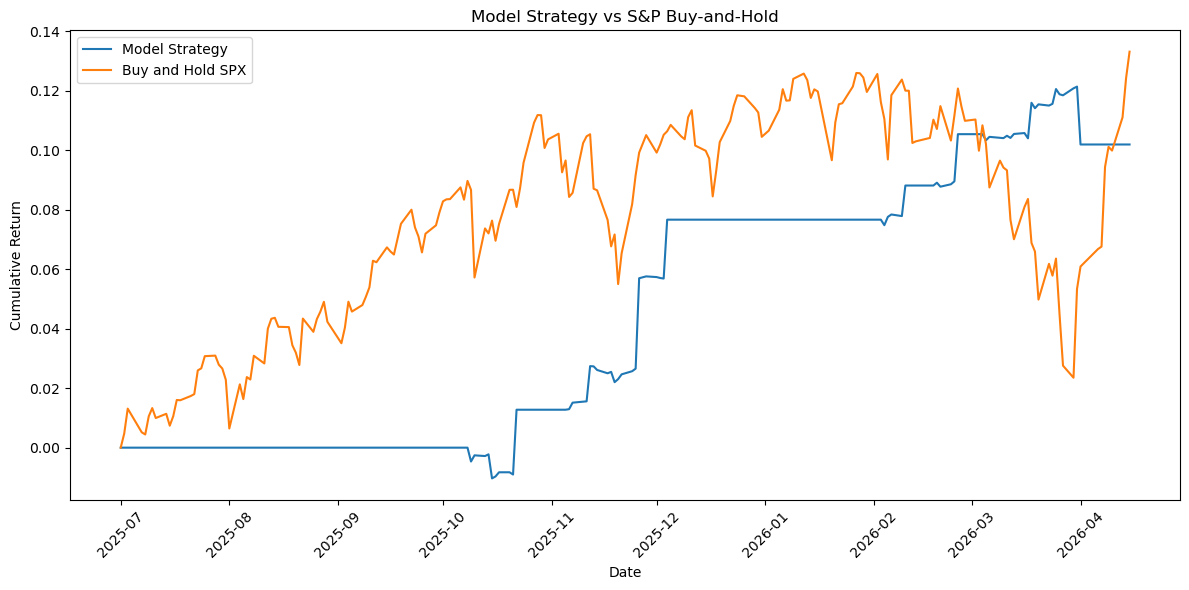

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

model_daily = outputs["model_strategy"]["daily_total_pnl"].copy()
snp_daily = outputs["buy_and_hold_spx"]["daily_total_pnl"].copy()

comp = (
    model_daily[["Date", "Cumulative Return"]]
    .rename(columns={"Cumulative Return": "Model Strategy"})
    .merge(
        snp_daily[["Date", "Cumulative Return"]]
        .rename(columns={"Cumulative Return": "Buy and Hold SPX"}),
        on="Date",
        how="outer",
    )
    .sort_values("Date")
)

comp = comp.ffill().fillna(0.0)

plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(comp["Date"]), comp["Model Strategy"], label="Model Strategy")
plt.plot(pd.to_datetime(comp["Date"]), comp["Buy and Hold SPX"], label="Buy and Hold SPX")
plt.title("Model Strategy vs S&P Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

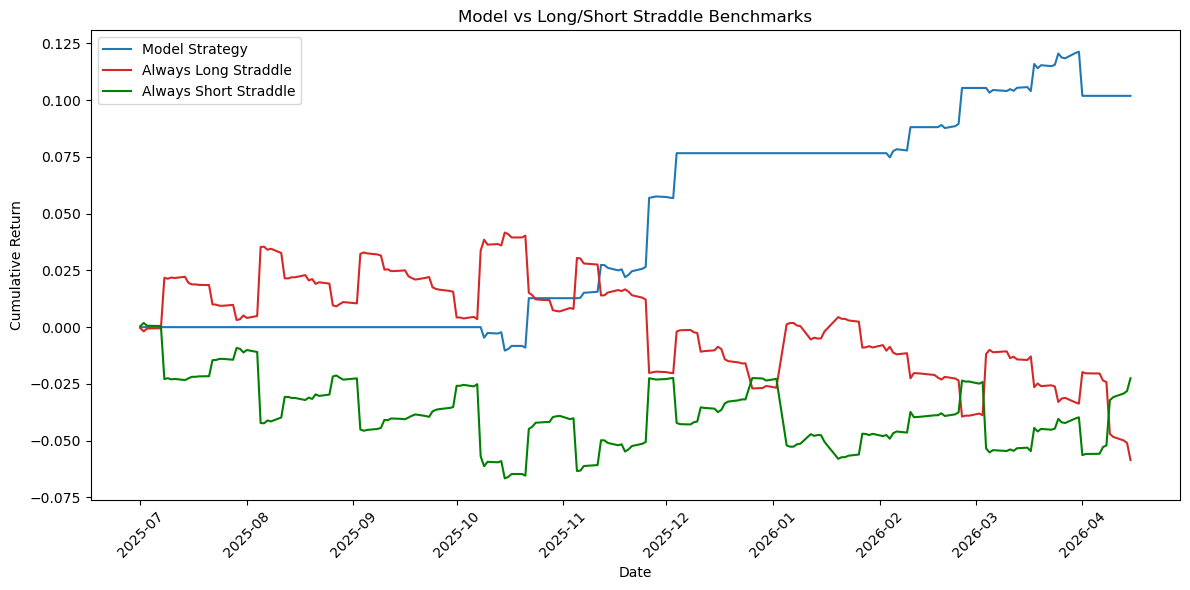

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    pd.to_datetime(comp["Date"]),
    comp["Model Strategy"],
    label="Model Strategy",
    color="tab:blue"
)

plt.plot(
    pd.to_datetime(comp["Date"]),
    comp["Always Long Straddle"],
    label="Always Long Straddle",
    color="tab:red"   # softer red
)

plt.plot(
    pd.to_datetime(comp["Date"]),
    comp["Always Short Straddle"],
    label="Always Short Straddle",
    color="green"
)

plt.title("Model vs Long/Short Straddle Benchmarks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

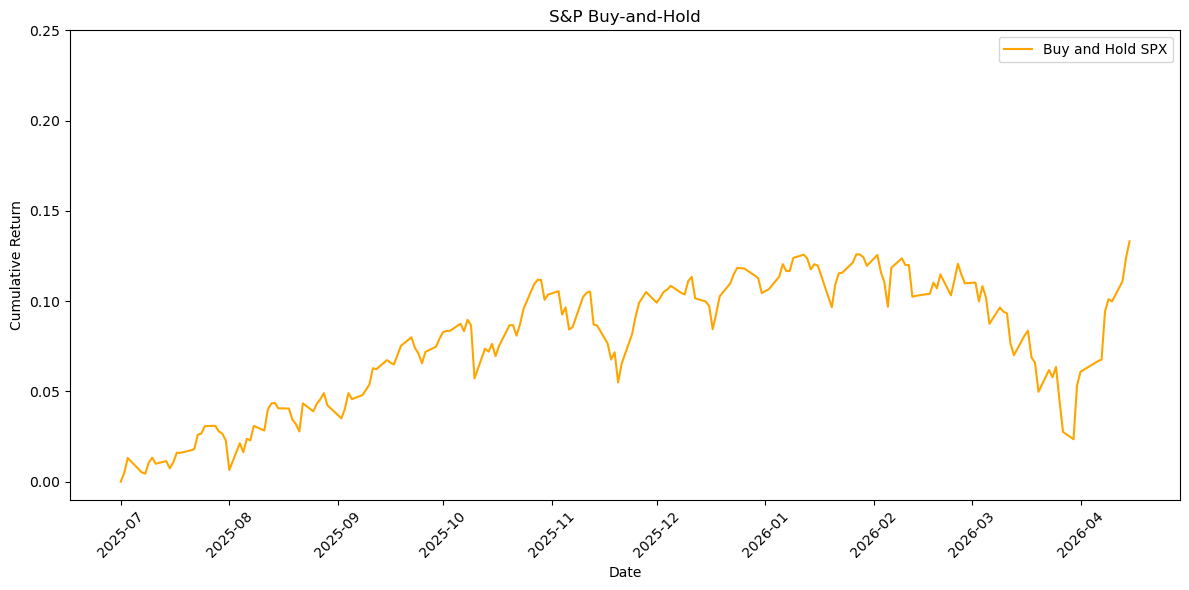

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

snp_daily = outputs["buy_and_hold_spx"]["daily_total_pnl"].copy()

plt.figure(figsize=(12, 6))
plt.plot(
    pd.to_datetime(snp_daily["Date"]),
    snp_daily["Cumulative Return"],
    label="Buy and Hold SPX",
    color="orange"
)

plt.ylim(-0.01, 0.25)

plt.title("S&P Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

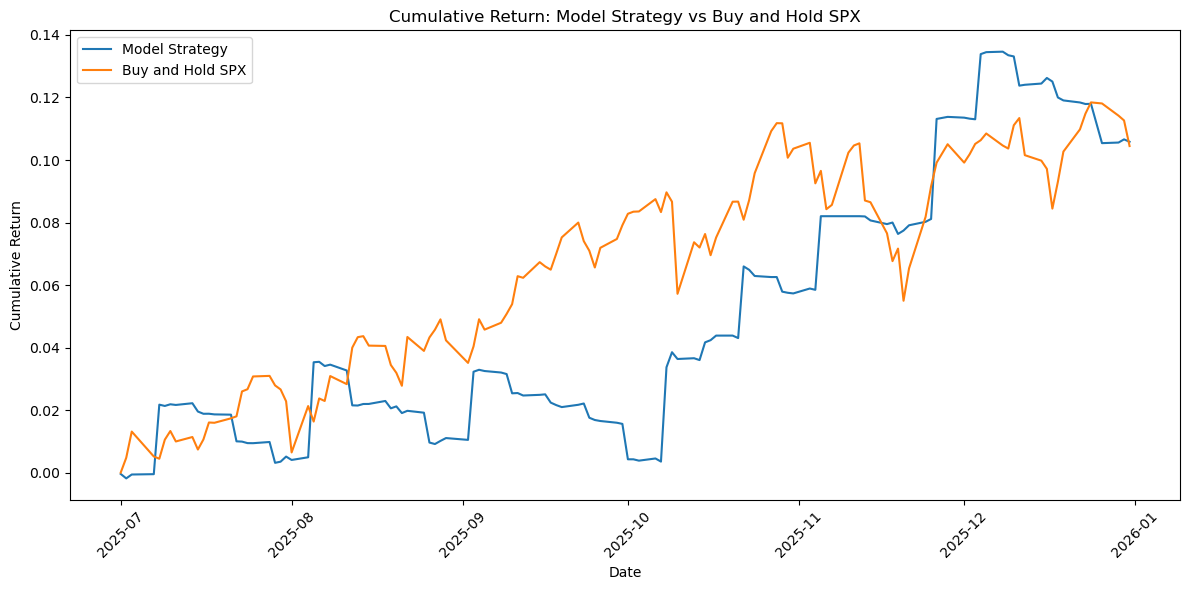

In [10]:
# Paste this into the next cell after running your current code.
# It creates a new graph with only Model Strategy vs Buy and Hold SPX.

model_daily = outputs["model_strategy"]["daily_total_pnl"].copy()
buy_hold_daily = outputs["buy_and_hold_spx"]["daily_total_pnl"].copy()

comp_two = (
    model_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": MODEL_STRATEGY_NAME})
    .merge(
        buy_hold_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": BUY_HOLD_NAME}),
        on="Date",
        how="outer",
    )
    .sort_values("Date")
)

comp_two = comp_two.ffill().fillna(0.0)

plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(comp_two["Date"]), comp_two[MODEL_STRATEGY_NAME], label=MODEL_STRATEGY_NAME)
plt.plot(pd.to_datetime(comp_two["Date"]), comp_two[BUY_HOLD_NAME], label=BUY_HOLD_NAME)
plt.title("Cumulative Return: Model Strategy vs Buy and Hold SPX")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Backtest Header
Training Start        : 2023-01-04
Training End          : 2025-06-30
Trading Start         : 2025-07-01
Trading End           : 2025-12-31
Training Rows         : 623
Trading Rows          : 0
Option Rows Used      : 128
Selected Vol Model    : ewma
Trading Window Days   : 5
Forecast Horizon Days : 21
Initial Capital       : 100000.0

Window-Level Results (Model Strategy)
Window Start Direction  Forecast Vol      IV  Vol Edge  Trade Taken Train Start Train End Used  Train Obs  Option TC  Hedge TC  Total TC  Straddle PnL   Hedge PnL   Window PnL  Cumulative PnL Forecast Status  Option Rows In Window
  2025-07-01      Long      0.155006 0.12800  0.027006         True  2023-01-04     2025-06-30      623.0      56.25       0.0     56.25        2225.0  -49.966952  2175.033048     2175.033048              ok                    5.0
  2025-07-09      Long      0.155006 0.12989  0.025116         True  2023-01-04     2025-06-30      623.0      91.25       0.0     91.25        -

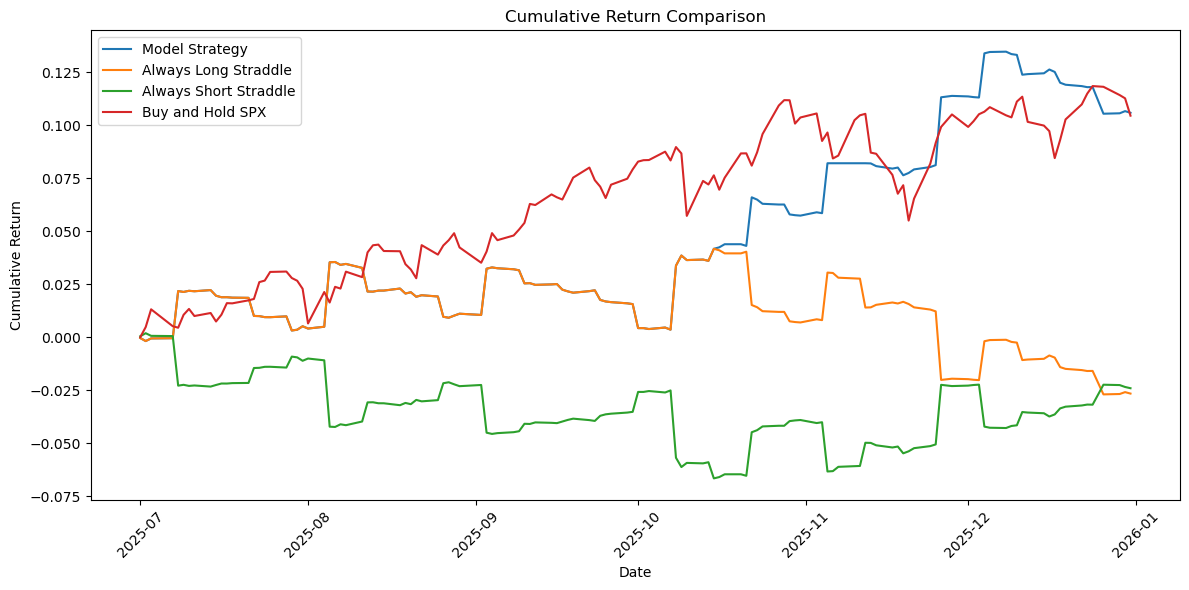

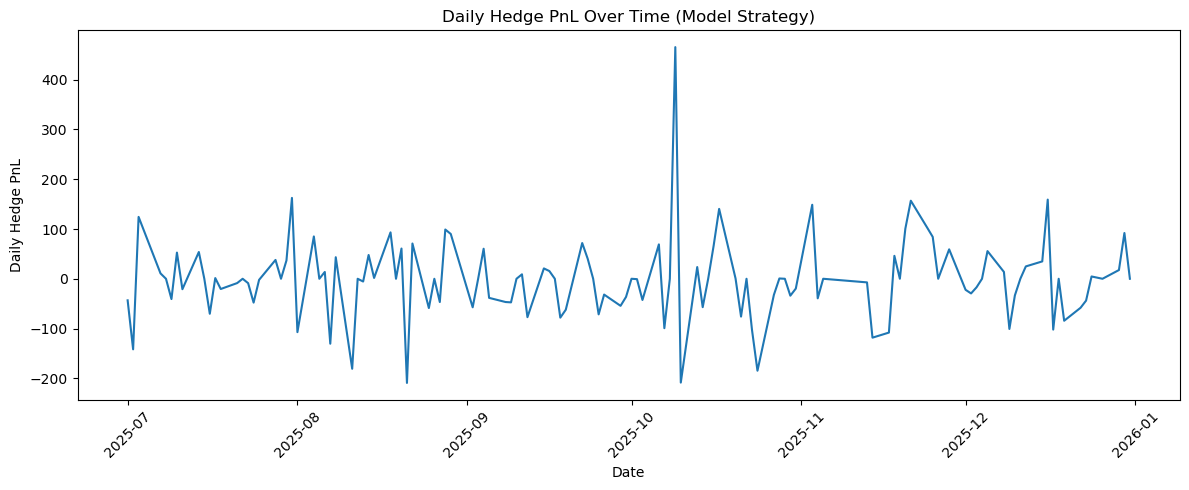

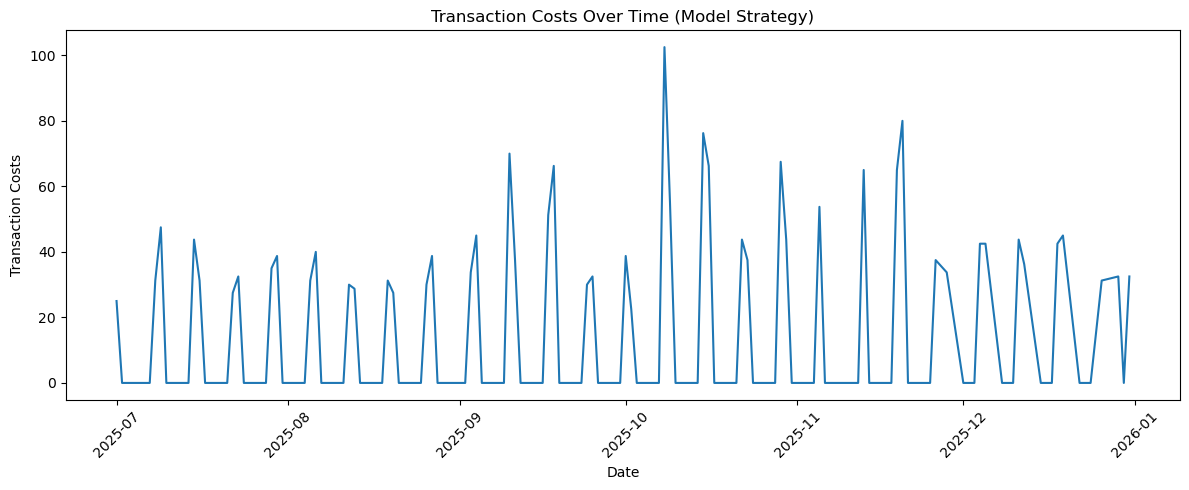

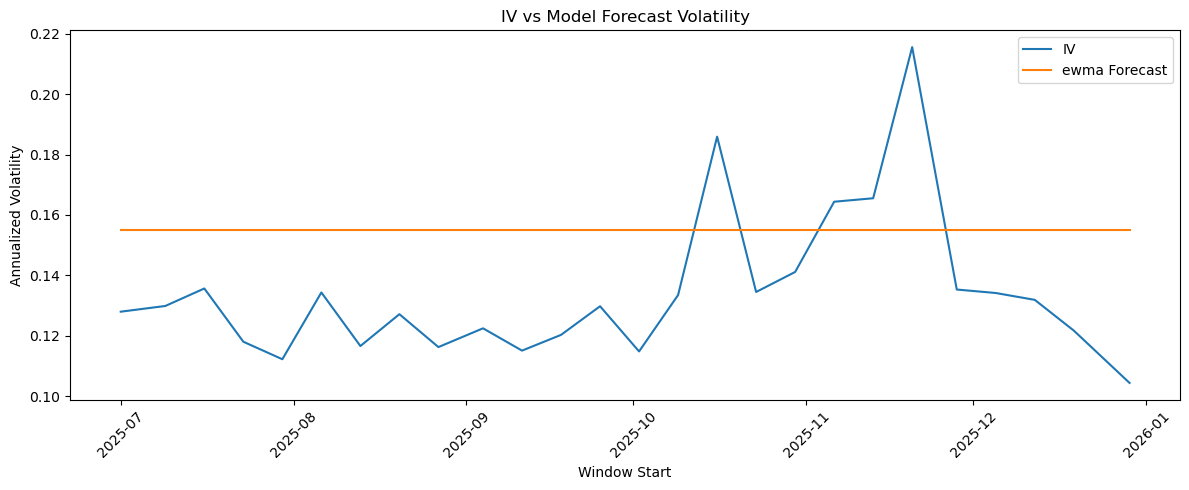













206.70624999999998


In [2]:
# Egarch

from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ======================================================================================
# Hyperparameters
# ======================================================================================
VOL_MODEL = "ewma"                # "egarch", "ewma", "gjrgarch", "garch11"
TRADING_WINDOW_DAYS = 5             # number of option dates per walk-forward trading window
FORECAST_HORIZON_DAYS = 21           # volatility forecast horizon in trading days
TRADING_DAYS_PER_YEAR = 252
TRADE_THRESHOLD = 0.01              # minimum absolute vol edge to trade
MAX_EDGE_FILTER = 0.50              # do not trade if absolute edge exceeds this value
HEDGE_TC_PER_UNIT = 0.0             # hedge transaction cost per 1 unit of underlying rebalanced
EWMA_LAMBDA = 0.94                  # RiskMetrics lambda
GARCH_SIMULATIONS = 5000            # used for multi-step arch forecasts when needed
MIN_TRAIN_LENGTH = 60               # minimum return observations to fit model
HEDGE_NEUTRALITY_TOL = 1e-10        # tolerance for net delta after hedge
CONTRACT_MULTIPLIER = 25.0          # We set the contract multiplier to 25 so that the average straddle premium (~206 × 25 ≈ 5,150) represents about 5% of the 100,000 capital base, ensuring each trade has a realistic and comparable level of capital at risk.
BUY_HOLD_UNITS = 1.0                # units of SPX spot for buy-and-hold benchmark
MAX_DAILY_HEDGE_PRINT_ROWS = 20     # compact daily hedge diagnostics display

# Normalization / performance reporting
INITIAL_CAPITAL = 100_000.0         # common capital base for return normalization

RETURNS_CSV_PATH = Path("data/processed/SPY_Close_modeling_2.5y.csv")
OPTIONS_XLSX_PATH = Path("data/processed/options_data_2025.xlsx")
OPTIONS_SHEET_NAME = "Delta_Trading"

INITIAL_TRAIN_START = pd.Timestamp("2023-01-04")
INITIAL_TRAIN_END = pd.Timestamp("2025-06-30")
TRADE_START = pd.Timestamp("2025-07-01")
TRADE_END = pd.Timestamp("2025-12-31")

MODEL_STRATEGY_NAME = "Model Strategy"
LONG_BENCHMARK_NAME = "Always Long Straddle"
SHORT_BENCHMARK_NAME = "Always Short Straddle"
BUY_HOLD_NAME = "Buy and Hold SPX"


# ======================================================================================
# Data structures
# ======================================================================================
@dataclass
class ForecastResult:
    model: str
    annualized_vol: Optional[float]
    daily_variance_path: Optional[np.ndarray]
    fit_status: str


# ======================================================================================
# Utility helpers
# ======================================================================================
def require_columns(df: pd.DataFrame, required: List[str], df_name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")


def format_date(x) -> str:
    if pd.isna(x):
        return "NaT"
    return pd.Timestamp(x).strftime("%Y-%m-%d")


def print_section(title: str) -> None:
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)


def print_kv(title: str, items: List[Tuple[str, object]]) -> None:
    print_section(title)
    width = max(len(k) for k, _ in items)
    for k, v in items:
        print(f"{k:<{width}} : {v}")


def printable_df(df: pd.DataFrame, round_cols: Optional[List[str]] = None, decimals: int = 6) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if np.issubdtype(out[col].dtype, np.datetime64):
            out[col] = out[col].dt.strftime("%Y-%m-%d")

    if round_cols is None:
        round_cols = [
            c for c in out.columns
            if pd.api.types.is_numeric_dtype(out[c]) and not pd.api.types.is_bool_dtype(out[c])
        ]

    for col in round_cols:
        if col in out.columns and not pd.api.types.is_bool_dtype(out[col]):
            out[col] = out[col].astype(float).round(decimals)

    return out


def print_compact_df(title: str, df: pd.DataFrame, max_rows: int = 30, decimals: int = 6) -> None:
    print_section(title)
    if df.empty:
        print("<empty>")
        return

    view = printable_df(df, decimals=decimals)
    if len(view) <= max_rows:
        print(view.to_string(index=False))
    else:
        head_n = max_rows // 2
        tail_n = max_rows - head_n
        print(view.head(head_n).to_string(index=False))
        print(f"\n... ({len(view) - max_rows} rows omitted) ...\n")
        print(view.tail(tail_n).to_string(index=False))


def add_to_ledger(ledger: Dict[pd.Timestamp, float], date: pd.Timestamp, value: float = 0.0) -> None:
    d = pd.Timestamp(date)
    ledger[d] = ledger.get(d, 0.0) + float(value)


def compute_max_drawdown_from_cumulative_return(cumulative_return: pd.Series) -> float:
    cr = pd.Series(cumulative_return).astype(float)
    if cr.empty:
        return 0.0

    equity = 1.0 + cr
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    return float(drawdown.min())


def compute_sharpe(daily_returns: pd.Series, trading_days_per_year: int) -> float:
    rets = pd.Series(daily_returns).astype(float)
    if len(rets) <= 1:
        return np.nan
    std = float(rets.std(ddof=1))
    if std <= 0:
        return np.nan
    return float(np.sqrt(trading_days_per_year) * rets.mean() / std)


def add_normalized_performance_columns(
    daily_total_df: pd.DataFrame,
    initial_capital: float,
) -> pd.DataFrame:
    df = daily_total_df.copy()

    if initial_capital <= 0:
        raise ValueError("initial_capital must be positive.")

    df["Daily Return"] = df["Strategy PnL"] / initial_capital
    df["Cumulative Return"] = (1.0 + df["Daily Return"]).cumprod() - 1.0
    df["Equity Curve"] = initial_capital * (1.0 + df["Cumulative Return"])

    return df


# ======================================================================================
# Data loading
# ======================================================================================
def load_returns_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Returns CSV not found: {path}")

    df = pd.read_csv(path)
    require_columns(df, ["Date", "log_return"], "Returns CSV")

    df = df[["Date", "log_return"]].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["log_return"] = pd.to_numeric(df["log_return"], errors="coerce")
    df = df.dropna(subset=["Date", "log_return"]).sort_values("Date")

    dupes = df.duplicated(subset=["Date"], keep="first")
    if dupes.any():
        print(f"Warning: dropping {dupes.sum()} duplicate return rows by date (keeping first).")
        df = df.loc[~dupes].copy()

    if df.empty:
        raise ValueError("Returns data is empty after parsing and cleaning.")

    return df.reset_index(drop=True)


def load_options_data(path: Path, sheet_name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Options workbook not found: {path}")

    raw = pd.read_excel(path, sheet_name=sheet_name)
    required_raw_cols = [
        "Date",
        "nearest straddle bid",
        "nearest straddle ask",
        "Straddle Delta",
        "Underlying (SPX Spot)",
        "nearest IV",
    ]
    require_columns(raw, required_raw_cols, "Options Excel sheet")

    rename_map = {
        "nearest straddle bid": "Straddle Bid",
        "nearest straddle ask": "Straddle Ask",
        "Straddle Delta": "Straddle Delta",
        "Underlying (SPX Spot)": "SPX Spot",
        "nearest IV": "IV",
    }

    df = raw.rename(columns=rename_map)[
        ["Date", "Straddle Bid", "Straddle Ask", "Straddle Delta", "SPX Spot", "IV"]
    ].copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Straddle Bid", "Straddle Ask", "Straddle Delta", "SPX Spot", "IV"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    before_drop = len(df)
    df = df.dropna(subset=["Date", "Straddle Bid", "Straddle Ask", "Straddle Delta", "SPX Spot", "IV"])
    dropped = before_drop - len(df)
    if dropped > 0:
        print(f"Warning: dropped {dropped} option rows with missing required values.")

    df["IV"] = df["IV"] / 100.0
    df = df.sort_values("Date")

    dupes = df.duplicated(subset=["Date"], keep="first")
    if dupes.any():
        print(f"Warning: dropping {dupes.sum()} duplicate option rows by date (keeping first).")
        df = df.loc[~dupes].copy()

    if df.empty:
        raise ValueError("Options data is empty after parsing and cleaning.")

    return df.reset_index(drop=True)


# ======================================================================================
# Volatility forecasts
# ======================================================================================
def import_arch_model():
    try:
        from arch import arch_model
    except ImportError as exc:
        raise ImportError(
            "The 'arch' package is required for egarch, gjrgarch, and garch11. "
            "Install it or switch VOL_MODEL to 'ewma'."
        ) from exc
    return arch_model


def ewma_forecast(returns: pd.Series, horizon: int, lam: float, trading_days: int) -> ForecastResult:
    r = pd.Series(returns).dropna().astype(float)
    if len(r) == 0:
        return ForecastResult(model="ewma", annualized_vol=None, daily_variance_path=None, fit_status="no_data")

    sigma2 = float(r.var(ddof=1))
    if not np.isfinite(sigma2) or sigma2 <= 0:
        sigma2 = float(np.mean(np.square(r))) if len(r) > 0 else 0.0

    for ret in r:
        sigma2 = lam * sigma2 + (1.0 - lam) * (ret ** 2)

    sigma2 = max(float(sigma2), 1e-16)
    var_path = np.repeat(sigma2, horizon)
    annualized_vol = float(np.sqrt(var_path.mean()) * np.sqrt(trading_days))
    return ForecastResult(model="ewma", annualized_vol=annualized_vol, daily_variance_path=var_path, fit_status="ok")


def garch_family_forecast(
    returns: pd.Series,
    model_name: str,
    horizon: int,
    trading_days: int,
    simulations: int,
) -> ForecastResult:
    arch_model = import_arch_model()

    r = pd.Series(returns).dropna().astype(float)
    if len(r) == 0:
        return ForecastResult(model=model_name, annualized_vol=None, daily_variance_path=None, fit_status="no_data")

    r_pct = r * 100.0

    if model_name == "egarch":
        model = arch_model(r_pct, mean="Zero", vol="EGARCH", p=1, o=0, q=1, dist="normal", rescale=False)
    elif model_name == "gjrgarch":
        model = arch_model(r_pct, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="normal", rescale=False)
    elif model_name == "garch11":
        model = arch_model(r_pct, mean="Zero", vol="GARCH", p=1, o=0, q=1, dist="normal", rescale=False)
    else:
        raise ValueError(f"Unsupported GARCH-family model: {model_name}")

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = model.fit(disp="off", show_warning=False)

        if horizon == 1:
            fcst = fit.forecast(horizon=1, reindex=False)
            var_path_pct2 = np.array([float(fcst.variance.iloc[-1, 0])], dtype=float)
        else:
            try:
                fcst = fit.forecast(
                    horizon=horizon,
                    method="simulation",
                    simulations=simulations,
                    reindex=False,
                )
                var_path_pct2 = fcst.variance.iloc[-1].to_numpy(dtype=float)
            except Exception:
                fcst = fit.forecast(horizon=1, reindex=False)
                one_step_var = float(fcst.variance.iloc[-1, 0])
                var_path_pct2 = np.repeat(one_step_var, horizon)

        var_path_pct2 = np.maximum(var_path_pct2, 1e-16)
        var_path = var_path_pct2 / (100.0 ** 2)
        annualized_vol = float(np.sqrt(var_path.mean()) * np.sqrt(trading_days))
        return ForecastResult(model=model_name, annualized_vol=annualized_vol, daily_variance_path=var_path, fit_status="ok")
    except Exception as exc:
        return ForecastResult(model=model_name, annualized_vol=None, daily_variance_path=None, fit_status=f"fit_failed: {exc}")


def forecast_volatility(
    returns: pd.Series,
    model_name: str,
    horizon: int,
    trading_days: int,
    ewma_lambda: float,
    simulations: int,
) -> ForecastResult:
    model_name = model_name.lower().strip()
    if model_name == "ewma":
        return ewma_forecast(returns, horizon=horizon, lam=ewma_lambda, trading_days=trading_days)
    if model_name in {"egarch", "gjrgarch", "garch11"}:
        return garch_family_forecast(
            returns=returns,
            model_name=model_name,
            horizon=horizon,
            trading_days=trading_days,
            simulations=simulations,
        )
    raise ValueError(f"Unsupported VOL_MODEL: {model_name}")


# ======================================================================================
# Walk-forward setup
# ======================================================================================
def make_windows(option_dates: pd.Series, window_len: int) -> List[pd.DatetimeIndex]:
    dates = pd.DatetimeIndex(pd.Series(option_dates).dropna().sort_values().unique())
    if len(dates) == 0:
        raise ValueError("No option dates available to create trading windows.")
    return [dates[i: i + window_len] for i in range(0, len(dates), window_len)]


def trade_direction_from_edge(vol_edge: Optional[float], threshold: float, max_edge: float) -> Tuple[str, bool, int]:
    if vol_edge is None or not np.isfinite(vol_edge):
        return "Flat", False, 0
    if abs(vol_edge) < threshold:
        return "Flat", False, 0
    if abs(vol_edge) > max_edge:
        return "Flat", False, 0
    if vol_edge > 0:
        return "Long", True, 1
    if vol_edge < 0:
        return "Short", True, -1
    return "Flat", False, 0


def build_walkforward_payloads(
    returns_df: pd.DataFrame,
    trading_options: pd.DataFrame,
) -> Tuple[List[dict], pd.DataFrame]:
    initial_train_returns = returns_df.loc[
        (returns_df["Date"] >= INITIAL_TRAIN_START) & (returns_df["Date"] <= INITIAL_TRAIN_END)
    ].copy()

    if initial_train_returns.empty:
        raise ValueError("Initial training period is empty.")

    windows = make_windows(trading_options["Date"], TRADING_WINDOW_DAYS)

    training_history = initial_train_returns.copy()
    current_train_cutoff = pd.Timestamp(INITIAL_TRAIN_END)
    payloads: List[dict] = []

    for window_index, window_dates in enumerate(windows, start=1):
        window_df = trading_options.loc[trading_options["Date"].isin(window_dates)].copy().sort_values("Date").reset_index(drop=True)
        if window_df.empty:
            raise ValueError(f"Window {window_index} produced empty option data.")

        train_start_used = pd.Timestamp(training_history["Date"].min())
        train_end_used = pd.Timestamp(training_history["Date"].max())
        train_obs = int(len(training_history))

        if train_obs < MIN_TRAIN_LENGTH:
            forecast = ForecastResult(
                model=VOL_MODEL,
                annualized_vol=None,
                daily_variance_path=None,
                fit_status=f"insufficient_training_obs<{MIN_TRAIN_LENGTH}",
            )
        else:
            forecast = forecast_volatility(
                returns=training_history["log_return"],
                model_name=VOL_MODEL,
                horizon=FORECAST_HORIZON_DAYS,
                trading_days=TRADING_DAYS_PER_YEAR,
                ewma_lambda=EWMA_LAMBDA,
                simulations=GARCH_SIMULATIONS,
            )

        first_row = window_df.iloc[0]
        last_row = window_df.iloc[-1]
        iv = float(first_row["IV"])
        forecast_vol = forecast.annualized_vol
        vol_edge = np.nan if forecast_vol is None else float(forecast_vol - iv)

        payloads.append(
            {
                "window_index": window_index,
                "window_start": pd.Timestamp(first_row["Date"]),
                "window_end": pd.Timestamp(last_row["Date"]),
                "window_df": window_df,
                "forecast_vol": forecast_vol,
                "iv": iv,
                "vol_edge": vol_edge,
                "forecast_status": forecast.fit_status,
                "train_start": train_start_used,
                "train_end_used": train_end_used,
                "train_obs": train_obs,
                "option_rows_in_window": int(len(window_df)),
            }
        )

        last_row_date = pd.Timestamp(last_row["Date"])
        new_returns = returns_df.loc[
            (returns_df["Date"] > current_train_cutoff) & (returns_df["Date"] <= last_row_date)
        ].copy()

        if not new_returns.empty:
            training_history = (
                pd.concat([training_history, new_returns], ignore_index=True)
                .drop_duplicates(subset=["Date"], keep="first")
                .sort_values("Date")
                .reset_index(drop=True)
            )

        current_train_cutoff = max(current_train_cutoff, last_row_date)

    payload_df = pd.DataFrame(
        [
            {
                "Window Start": p["window_start"],
                "Window End": p["window_end"],
                "Forecast Vol": p["forecast_vol"],
                "IV": p["iv"],
                "Vol Edge": p["vol_edge"],
                "Forecast Status": p["forecast_status"],
                "Train Start": p["train_start"],
                "Train End Used": p["train_end_used"],
                "Train Obs": p["train_obs"],
                "Option Rows In Window": p["option_rows_in_window"],
            }
            for p in payloads
        ]
    )

    return payloads, payload_df


# ======================================================================================
# Strategy engine
# ======================================================================================
def resolve_strategy_direction(strategy_mode: str, vol_edge: Optional[float]) -> Tuple[str, bool, int]:
    strategy_mode = strategy_mode.lower().strip()

    if strategy_mode == "model":
        return trade_direction_from_edge(vol_edge=vol_edge, threshold=TRADE_THRESHOLD, max_edge=MAX_EDGE_FILTER)

    if strategy_mode == "always_long":
        return "Long", True, 1

    if strategy_mode == "always_short":
        return "Short", True, -1

    raise ValueError(f"Unsupported strategy_mode: {strategy_mode}")


def calculate_option_pnl_and_tc(
    entry_bid: float,
    entry_ask: float,
    exit_bid: float,
    exit_ask: float,
    direction_sign: int,
    multiplier: float,
) -> Tuple[float, float, float, float]:
    entry_tc = 0.5 * abs(entry_ask - entry_bid) * multiplier
    exit_tc = 0.5 * abs(exit_ask - exit_bid) * multiplier
    option_tc = entry_tc + exit_tc

    if direction_sign == 1:
        # Long straddle: enter at ask, exit at bid.
        straddle_pnl = (exit_bid - entry_ask) * multiplier
    elif direction_sign == -1:
        # Short straddle: enter at bid, exit at ask.
        straddle_pnl = (entry_bid - exit_ask) * multiplier
    else:
        straddle_pnl = 0.0

    # Option TC is reported explicitly, but straddle_pnl already reflects executable bid/ask pricing.
    return float(straddle_pnl), float(option_tc), float(entry_tc), float(exit_tc)


def execute_trade_window(
    window_df: pd.DataFrame,
    direction: str,
    trade_taken: bool,
    direction_sign: int,
) -> Tuple[Dict[str, float], List[Dict[str, object]], Dict[pd.Timestamp, float], Dict[pd.Timestamp, float]]:
    option_tc = 0.0
    hedge_tc = 0.0
    total_tc = 0.0
    straddle_pnl = 0.0
    hedge_pnl = 0.0
    window_pnl = 0.0

    hedge_records: List[Dict[str, object]] = []
    daily_pnl_ledger: Dict[pd.Timestamp, float] = {}
    daily_tc_ledger: Dict[pd.Timestamp, float] = {}

    if not trade_taken or direction_sign == 0:
        return (
            {
                "Option TC": option_tc,
                "Hedge TC": hedge_tc,
                "Total TC": total_tc,
                "Straddle PnL": straddle_pnl,
                "Hedge PnL": hedge_pnl,
                "Window PnL": window_pnl,
            },
            hedge_records,
            daily_pnl_ledger,
            daily_tc_ledger,
        )

    first_row = window_df.iloc[0]
    last_row = window_df.iloc[-1]

    straddle_pnl, option_tc, entry_option_tc, exit_option_tc = calculate_option_pnl_and_tc(
        entry_bid=float(first_row["Straddle Bid"]),
        entry_ask=float(first_row["Straddle Ask"]),
        exit_bid=float(last_row["Straddle Bid"]),
        exit_ask=float(last_row["Straddle Ask"]),
        direction_sign=direction_sign,
        multiplier=CONTRACT_MULTIPLIER,
    )

    add_to_ledger(daily_tc_ledger, pd.Timestamp(first_row["Date"]), entry_option_tc)
    add_to_ledger(daily_tc_ledger, pd.Timestamp(last_row["Date"]), exit_option_tc)

    prev_hedge_pos = 0.0

    if len(window_df) >= 2:
        for i in range(len(window_df) - 1):
            cur = window_df.iloc[i]
            nxt = window_df.iloc[i + 1]

            cur_date = pd.Timestamp(cur["Date"])
            cur_spot = float(cur["SPX Spot"])
            nxt_spot = float(nxt["SPX Spot"])
            cur_delta = float(cur["Straddle Delta"])

            # Long straddle -> hedge with -delta.
            # Short straddle -> hedge with +delta.
            target_hedge_pos = -direction_sign * cur_delta
            net_delta_after_hedge = direction_sign * cur_delta + target_hedge_pos

            daily_hedge_tc = abs(target_hedge_pos - prev_hedge_pos) * HEDGE_TC_PER_UNIT * CONTRACT_MULTIPLIER
            daily_hedge_pnl = target_hedge_pos * (nxt_spot - cur_spot) * CONTRACT_MULTIPLIER

            hedge_tc += daily_hedge_tc
            hedge_pnl += daily_hedge_pnl

            hedge_records.append(
                {
                    "Date": cur_date,
                    "Window Start": pd.Timestamp(first_row["Date"]),
                    "Direction": direction,
                    "SPX Spot": cur_spot,
                    "Straddle Delta": cur_delta,
                    "Hedge Position": target_hedge_pos,
                    "Net Delta After Hedge": net_delta_after_hedge,
                    "Daily Hedge PnL": daily_hedge_pnl,
                    "Daily Hedge TC": daily_hedge_tc,
                }
            )

            add_to_ledger(daily_pnl_ledger, cur_date, daily_hedge_pnl - daily_hedge_tc)
            add_to_ledger(daily_tc_ledger, cur_date, daily_hedge_tc)

            prev_hedge_pos = target_hedge_pos

    final_date = pd.Timestamp(last_row["Date"])
    final_delta = float(last_row["Straddle Delta"])
    final_spot = float(last_row["SPX Spot"])

    unwind_tc = abs(prev_hedge_pos) * HEDGE_TC_PER_UNIT * CONTRACT_MULTIPLIER
    hedge_tc += unwind_tc

    hedge_records.append(
        {
            "Date": final_date,
            "Window Start": pd.Timestamp(first_row["Date"]),
            "Direction": direction,
            "SPX Spot": final_spot,
            "Straddle Delta": final_delta,
            "Hedge Position": 0.0,
            "Net Delta After Hedge": 0.0,
            "Daily Hedge PnL": 0.0,
            "Daily Hedge TC": unwind_tc,
        }
    )

    add_to_ledger(daily_pnl_ledger, final_date, straddle_pnl - unwind_tc)
    add_to_ledger(daily_tc_ledger, final_date, unwind_tc)

    total_tc = option_tc + hedge_tc
    window_pnl = straddle_pnl + hedge_pnl - hedge_tc

    return (
        {
            "Option TC": float(option_tc),
            "Hedge TC": float(hedge_tc),
            "Total TC": float(total_tc),
            "Straddle PnL": float(straddle_pnl),
            "Hedge PnL": float(hedge_pnl),
            "Window PnL": float(window_pnl),
        },
        hedge_records,
        daily_pnl_ledger,
        daily_tc_ledger,
    )


def finalize_daily_totals(
    trading_dates: pd.DatetimeIndex,
    daily_pnl_ledger: Dict[pd.Timestamp, float],
    daily_tc_ledger: Dict[pd.Timestamp, float],
    initial_capital: float,
) -> pd.DataFrame:
    daily_total_df = pd.DataFrame(index=trading_dates)
    daily_total_df.index.name = "Date"
    daily_total_df["Strategy PnL"] = 0.0
    daily_total_df["Transaction Costs"] = 0.0

    for dt, pnl in daily_pnl_ledger.items():
        if dt not in daily_total_df.index:
            daily_total_df.loc[dt] = 0.0
        daily_total_df.loc[dt, "Strategy PnL"] += pnl

    for dt, tc in daily_tc_ledger.items():
        if dt not in daily_total_df.index:
            daily_total_df.loc[dt] = 0.0
        daily_total_df.loc[dt, "Transaction Costs"] += tc

    daily_total_df = daily_total_df.sort_index()
    daily_total_df["Cumulative PnL"] = daily_total_df["Strategy PnL"].cumsum()
    daily_total_df = daily_total_df.reset_index()

    daily_total_df = add_normalized_performance_columns(
        daily_total_df=daily_total_df,
        initial_capital=initial_capital,
    )

    return daily_total_df


def summarize_hedge_quality(daily_hedge_df: pd.DataFrame) -> pd.DataFrame:
    if daily_hedge_df.empty:
        max_abs_net_delta = 0.0
        mean_abs_net_delta = 0.0
        neutralized = True
    else:
        max_abs_net_delta = float(daily_hedge_df["Net Delta After Hedge"].abs().max())
        mean_abs_net_delta = float(daily_hedge_df["Net Delta After Hedge"].abs().mean())
        neutralized = bool(max_abs_net_delta <= HEDGE_NEUTRALITY_TOL)

    return pd.DataFrame(
        {
            "Metric": [
                "Max |Net Delta After Hedge|",
                "Mean |Net Delta After Hedge|",
                "Hedging Effectively Neutralized Each Day",
            ],
            "Value": [max_abs_net_delta, mean_abs_net_delta, neutralized],
        }
    )


def summarize_strategy_performance(
    strategy_name: str,
    daily_total_df: pd.DataFrame,
    window_results: Optional[pd.DataFrame],
) -> pd.DataFrame:
    overall_pnl = float(daily_total_df["Strategy PnL"].sum())
    total_return = float(daily_total_df["Cumulative Return"].iloc[-1]) if not daily_total_df.empty else 0.0
    sharpe = compute_sharpe(daily_total_df["Daily Return"], TRADING_DAYS_PER_YEAR)
    max_drawdown = compute_max_drawdown_from_cumulative_return(daily_total_df["Cumulative Return"])
    total_tc = float(daily_total_df["Transaction Costs"].sum())

    if window_results is None or window_results.empty:
        total_windows = 1
        trades_taken = 1
    else:
        total_windows = int(len(window_results))
        trades_taken = int(window_results["Trade Taken"].sum())

    return pd.DataFrame(
        {
            "Strategy": [strategy_name],
            "Overall PnL": [overall_pnl],
            "Total Return": [total_return],
            "Sharpe Ratio": [sharpe],
            "Max Drawdown": [max_drawdown],
            "Total TC": [total_tc],
            "Total Windows": [total_windows],
            "Trades Taken": [trades_taken],
        }
    )


def run_straddle_strategy(
    strategy_mode: str,
    strategy_name: str,
    window_payloads: List[dict],
    trading_dates: pd.DatetimeIndex,
    initial_capital: float,
) -> Dict[str, pd.DataFrame]:
    window_records: List[Dict[str, object]] = []
    hedge_records: List[Dict[str, object]] = []

    daily_pnl_ledger: Dict[pd.Timestamp, float] = {}
    daily_tc_ledger: Dict[pd.Timestamp, float] = {}

    cumulative_pnl = 0.0

    for payload in window_payloads:
        window_df = payload["window_df"]
        vol_edge = payload["vol_edge"]
        vol_edge_for_decision = None if pd.isna(vol_edge) else float(vol_edge)

        direction, trade_taken, direction_sign = resolve_strategy_direction(strategy_mode, vol_edge_for_decision)

        window_metrics, window_hedge_records, window_pnl_ledger, window_tc_ledger = execute_trade_window(
            window_df=window_df,
            direction=direction,
            trade_taken=trade_taken,
            direction_sign=direction_sign,
        )

        for dt, pnl in window_pnl_ledger.items():
            add_to_ledger(daily_pnl_ledger, dt, pnl)
        for dt, tc in window_tc_ledger.items():
            add_to_ledger(daily_tc_ledger, dt, tc)

        hedge_records.extend(window_hedge_records)

        cumulative_pnl += window_metrics["Window PnL"]

        window_records.append(
            {
                "Window Start": payload["window_start"],
                "Direction": direction,
                "Forecast Vol": payload["forecast_vol"],
                "IV": payload["iv"],
                "Vol Edge": payload["vol_edge"],
                "Trade Taken": bool(trade_taken),
                "Train Start": payload["train_start"],
                "Train End Used": payload["train_end_used"],
                "Train Obs": payload["train_obs"],
                "Option TC": window_metrics["Option TC"],
                "Hedge TC": window_metrics["Hedge TC"],
                "Total TC": window_metrics["Total TC"],
                "Straddle PnL": window_metrics["Straddle PnL"],
                "Hedge PnL": window_metrics["Hedge PnL"],
                "Window PnL": window_metrics["Window PnL"],
                "Cumulative PnL": cumulative_pnl,
                "Forecast Status": payload["forecast_status"],
                "Option Rows In Window": payload["option_rows_in_window"],
            }
        )

    window_results = pd.DataFrame(window_records)
    daily_hedge_df = pd.DataFrame(hedge_records)
    if not daily_hedge_df.empty:
        daily_hedge_df = daily_hedge_df.sort_values(["Window Start", "Date"]).reset_index(drop=True)

    daily_total_df = finalize_daily_totals(
        trading_dates=trading_dates,
        daily_pnl_ledger=daily_pnl_ledger,
        daily_tc_ledger=daily_tc_ledger,
        initial_capital=initial_capital,
    )

    if not np.isclose(float(window_results["Window PnL"].sum()), float(daily_total_df["Strategy PnL"].sum()), atol=1e-8):
        diff = float(window_results["Window PnL"].sum() - daily_total_df["Strategy PnL"].sum())
        raise ValueError(f"{strategy_name} PnL reconciliation failed. Window sum minus daily sum = {diff:.10f}")

    hedge_quality = summarize_hedge_quality(daily_hedge_df)
    tc_summary = window_results[["Window Start", "Direction", "Option TC", "Hedge TC", "Total TC"]].copy()
    performance = summarize_strategy_performance(strategy_name, daily_total_df, window_results)

    return {
        "window_results": window_results,
        "daily_hedge_diagnostics": daily_hedge_df,
        "hedge_quality_summary": hedge_quality,
        "transaction_cost_summary": tc_summary,
        "daily_total_pnl": daily_total_df,
        "performance_metrics": performance,
    }


def run_buy_and_hold(trading_options: pd.DataFrame, initial_capital: float) -> Dict[str, pd.DataFrame]:
    spot_df = trading_options[["Date", "SPX Spot"]].copy().sort_values("Date").reset_index(drop=True)
    if spot_df.empty:
        raise ValueError("Trading-period spot data is empty for buy-and-hold benchmark.")

    spot_df["Daily Return"] = spot_df["SPX Spot"].pct_change().fillna(0.0)
    spot_df["Strategy PnL"] = spot_df["Daily Return"] * initial_capital
    spot_df["Transaction Costs"] = 0.0
    spot_df["Cumulative Return"] = (1.0 + spot_df["Daily Return"]).cumprod() - 1.0
    spot_df["Equity Curve"] = initial_capital * (1.0 + spot_df["Cumulative Return"])
    spot_df["Cumulative PnL"] = spot_df["Equity Curve"] - initial_capital

    daily_total_df = spot_df[
        ["Date", "Strategy PnL", "Transaction Costs", "Cumulative PnL", "Daily Return", "Cumulative Return", "Equity Curve"]
    ].copy()

    performance = summarize_strategy_performance(BUY_HOLD_NAME, daily_total_df, None)

    return {
        "daily_total_pnl": daily_total_df,
        "performance_metrics": performance,
    }


# ======================================================================================
# Plotting
# ======================================================================================
def plot_cumulative_comparison(
    model_daily: pd.DataFrame,
    long_daily: pd.DataFrame,
    short_daily: pd.DataFrame,
    buy_hold_daily: pd.DataFrame,
) -> None:
    comp = (
        model_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": MODEL_STRATEGY_NAME})
        .merge(
            long_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": LONG_BENCHMARK_NAME}),
            on="Date",
            how="outer",
        )
        .merge(
            short_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": SHORT_BENCHMARK_NAME}),
            on="Date",
            how="outer",
        )
        .merge(
            buy_hold_daily[["Date", "Cumulative Return"]].rename(columns={"Cumulative Return": BUY_HOLD_NAME}),
            on="Date",
            how="outer",
        )
        .sort_values("Date")
    )

    comp = comp.ffill().fillna(0.0)

    plt.figure(figsize=(12, 6))
    for col in [MODEL_STRATEGY_NAME, LONG_BENCHMARK_NAME, SHORT_BENCHMARK_NAME, BUY_HOLD_NAME]:
        plt.plot(pd.to_datetime(comp["Date"]), comp[col], label=col)
    plt.title("Cumulative Return Comparison")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()


def plot_daily_hedge_pnl(daily_hedge_df: pd.DataFrame, title: str) -> None:
    if daily_hedge_df.empty:
        hedge_plot_df = pd.DataFrame({"Date": [], "Daily Hedge PnL": []})
    else:
        hedge_plot_df = daily_hedge_df.groupby("Date", as_index=False)["Daily Hedge PnL"].sum()

    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(hedge_plot_df["Date"]), hedge_plot_df["Daily Hedge PnL"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Daily Hedge PnL")
    plt.xticks(rotation=45)
    plt.tight_layout()


def plot_transaction_costs(daily_total_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(daily_total_df["Date"]), daily_total_df["Transaction Costs"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Transaction Costs")
    plt.xticks(rotation=45)
    plt.tight_layout()


def plot_iv_vs_forecast(window_results: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(window_results["Window Start"]), window_results["IV"], label="IV")
    plt.plot(pd.to_datetime(window_results["Window Start"]), window_results["Forecast Vol"], label=f"{VOL_MODEL} Forecast")
    plt.title("IV vs Model Forecast Volatility")
    plt.xlabel("Window Start")
    plt.ylabel("Annualized Volatility")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()


# ======================================================================================
# Main
# ======================================================================================
def main() -> Dict[str, Dict[str, pd.DataFrame]]:
    pd.set_option("display.width", 240)
    pd.set_option("display.max_columns", 50)

    returns_df = load_returns_data(RETURNS_CSV_PATH)
    options_df = load_options_data(OPTIONS_XLSX_PATH, OPTIONS_SHEET_NAME)

    initial_train_returns = returns_df.loc[
        (returns_df["Date"] >= INITIAL_TRAIN_START) & (returns_df["Date"] <= INITIAL_TRAIN_END)
    ].copy()
    trading_returns = returns_df.loc[
        (returns_df["Date"] >= TRADE_START) & (returns_df["Date"] <= TRADE_END)
    ].copy()
    trading_options = options_df.loc[
        (options_df["Date"] >= TRADE_START) & (options_df["Date"] <= TRADE_END)
    ].copy()

    if initial_train_returns.empty:
        raise ValueError("Initial training returns slice is empty.")
    if trading_options.empty:
        raise ValueError("Trading options slice is empty.")

    print_kv(
        "Backtest Header",
        [
            ("Training Start", format_date(INITIAL_TRAIN_START)),
            ("Training End", format_date(INITIAL_TRAIN_END)),
            ("Trading Start", format_date(TRADE_START)),
            ("Trading End", format_date(TRADE_END)),
            ("Training Rows", len(initial_train_returns)),
            ("Trading Rows", len(trading_returns)),
            ("Option Rows Used", len(trading_options)),
            ("Selected Vol Model", VOL_MODEL),
            ("Trading Window Days", TRADING_WINDOW_DAYS),
            ("Forecast Horizon Days", FORECAST_HORIZON_DAYS),
            ("Initial Capital", INITIAL_CAPITAL),
        ],
    )

    window_payloads, forecast_iv_summary = build_walkforward_payloads(
        returns_df=returns_df,
        trading_options=trading_options,
    )

    trading_dates = pd.DatetimeIndex(trading_options["Date"].sort_values().unique())

    model_results = run_straddle_strategy(
        strategy_mode="model",
        strategy_name=MODEL_STRATEGY_NAME,
        window_payloads=window_payloads,
        trading_dates=trading_dates,
        initial_capital=INITIAL_CAPITAL,
    )
    long_results = run_straddle_strategy(
        strategy_mode="always_long",
        strategy_name=LONG_BENCHMARK_NAME,
        window_payloads=window_payloads,
        trading_dates=trading_dates,
        initial_capital=INITIAL_CAPITAL,
    )
    short_results = run_straddle_strategy(
        strategy_mode="always_short",
        strategy_name=SHORT_BENCHMARK_NAME,
        window_payloads=window_payloads,
        trading_dates=trading_dates,
        initial_capital=INITIAL_CAPITAL,
    )
    buy_hold_results = run_buy_and_hold(
        trading_options=trading_options,
        initial_capital=INITIAL_CAPITAL,
    )

    benchmark_comparison = pd.concat(
        [
            model_results["performance_metrics"],
            long_results["performance_metrics"],
            short_results["performance_metrics"],
            buy_hold_results["performance_metrics"],
        ],
        ignore_index=True,
    )

    benchmark_comparison = benchmark_comparison.sort_values("Total Return", ascending=False).reset_index(drop=True)

    model_window_results = model_results["window_results"]
    model_daily_hedge = model_results["daily_hedge_diagnostics"]
    model_hedge_quality = model_results["hedge_quality_summary"]
    model_tc_summary = model_results["transaction_cost_summary"]

    print_compact_df("Window-Level Results (Model Strategy)", model_window_results, max_rows=60, decimals=6)
    print_compact_df("Daily Hedge Diagnostics (Model Strategy, Compact)", model_daily_hedge, max_rows=MAX_DAILY_HEDGE_PRINT_ROWS, decimals=6)
    print_compact_df("Hedge-Quality Summary (Model Strategy)", model_hedge_quality, max_rows=10, decimals=10)
    print_compact_df("Transaction-Cost Summary (Model Strategy)", model_tc_summary, max_rows=60, decimals=6)
    print_compact_df("Benchmark Comparison", benchmark_comparison, max_rows=10, decimals=6)
    print_compact_df("Forecast vs IV by Window", forecast_iv_summary, max_rows=60, decimals=6)

    plot_cumulative_comparison(
        model_daily=model_results["daily_total_pnl"],
        long_daily=long_results["daily_total_pnl"],
        short_daily=short_results["daily_total_pnl"],
        buy_hold_daily=buy_hold_results["daily_total_pnl"],
    )
    plot_daily_hedge_pnl(model_daily_hedge, "Daily Hedge PnL Over Time (Model Strategy)")
    plot_transaction_costs(model_results["daily_total_pnl"], "Transaction Costs Over Time (Model Strategy)")
    plot_iv_vs_forecast(model_window_results)
    plt.show()
    print('\n\n\n\n\n\n\n\n\n\n\n')
    print(trading_options["Straddle Ask"].mean())
    return {
        "model_strategy": model_results,
        "always_long_straddle": long_results,
        "always_short_straddle": short_results,
        "buy_and_hold_spx": buy_hold_results,
        "forecast_iv_summary": {"table": forecast_iv_summary},
        "benchmark_comparison": {"table": benchmark_comparison},
    }


if __name__ == "__main__":
    outputs = main()

In [13]:
print(returns_df["Date"].max())

NameError: name 'returns_df' is not defined